# 02 — Data Preprocessing, Master Dataset & Feature Artifacts

**Mục tiêu của notebook này**

Notebook này chịu trách nhiệm chuẩn bị toàn bộ dữ liệu trung gian cho các notebook modeling và integration phía sau, đồng thời bổ sung đầy đủ phần giải thích để bám rubric và báo cáo:

1. Load và kiểm tra **đủ 9 bảng CSV** của bộ Olist.
2. Chuẩn hóa kiểu dữ liệu, xử lý duplicate an toàn và chuẩn hóa khóa join.
3. Thực hiện merge theo **grain 1 dòng = 1 order** nhưng vẫn **đi qua đủ 9 bảng** bằng cách:
   - merge trực tiếp `orders`, `customers`, `order_items`, `order_payments`, `order_reviews`;
   - dùng `products` + `category_translation` để chuẩn hóa danh mục;
   - dùng `sellers` + `geolocation` để tạo seller/customer geo features ở mức đơn hàng.
4. Xử lý missing values theo chiến lược rõ ràng, không fill bừa làm bẩn dữ liệu.
5. Tạo các artifact đầu ra dùng cho các notebook sau:
   - `orders_base_final`
   - `rfm_df`
   - `ratings_df`
   - `transactions_df`
   - `transactions_order_category_df`
   - `product_lookup_df`
6. Bổ sung **TF-IDF artifact** và **preprocessing pipeline demo** để bám yêu cầu rubric/báo cáo ở mức cao nhất mà **không đổi tên các file lõi** mà notebook khác đang dùng.

**Nguyên tắc tương thích**
- Không đổi tên các file đầu ra lõi mà notebook khác đang đọc.
- Không xóa các cột lõi đã được notebook 03 / 04 / 05 / 06 / 07 / 08 sử dụng.
- Chỉ **bổ sung** cột/phụ phẩm mới nếu cần để tăng khả năng giải thích và tăng điểm rubric.


## Cell 1 — Import thư viện

Cell này import toàn bộ thư viện cần dùng cho:
- xử lý dữ liệu bằng `pandas`, `numpy`;
- lưu artifact bằng `joblib`, `json`, `scipy.sparse`;
- hiển thị bảng/markdown trong notebook;
- xây dựng **preprocessing pipeline demo** bằng Scikit-learn để phục vụ rubric và báo cáo.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

import joblib
from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler


## Cell 2 — Khai báo file raw bắt buộc và hàm resolve đường dẫn

Cell này làm 2 việc:
- định nghĩa **danh sách file raw bắt buộc** để notebook fail sớm nếu thiếu dữ liệu;
- tự tìm `data/raw` và `data/processed` theo nhiều candidate path để notebook chạy ổn định hơn trên các môi trường khác nhau.

Điểm quan trọng:
- giữ nguyên thư mục output là `data/processed`;
- không hard-code một path duy nhất để tránh lỗi khi đổi vị trí notebook.


In [2]:
RAW_FILENAMES = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

def resolve_project_paths():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path("."),
        Path(".."),
        Path("../.."),
    ]

    checked = []
    for base in candidates:
        base = base.resolve()
        raw_dir = base / "data" / "raw"
        processed_dir = base / "data" / "processed"
        checked.append(str(raw_dir))

        if raw_dir.exists() and all((raw_dir / fname).exists() for fname in RAW_FILENAMES.values()):
            processed_dir.mkdir(parents=True, exist_ok=True)
            return base, raw_dir, processed_dir

    raise FileNotFoundError(
        "Không tìm thấy thư mục data/raw chứa đủ 9 file CSV bắt buộc.\n"
        + "Các path đã kiểm tra:\n- "
        + "\n- ".join(checked)
    )


## Cell 3 — Resolve `RAW_DIR` và `PROCESSED_DIR`

Cell này chạy hàm resolve ở trên và in ra đường dẫn đang dùng để:
- minh bạch môi trường chạy;
- giúp debug nếu notebook bị lỗi vì path.


In [3]:
BASE_DIR, RAW_DIR, PROCESSED_DIR = resolve_project_paths()

print("BASE_DIR     :", BASE_DIR)
print("RAW_DIR      :", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)


BASE_DIR     : C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project
RAW_DIR      : C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\data\raw
PROCESSED_DIR: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\data\processed


## Cell 4 — Load đủ 9 file CSV của bộ dữ liệu Olist

Cell này đọc toàn bộ 9 file CSV và hiển thị bảng tổng quan số dòng/số cột.

Ý nghĩa:
- đây là bằng chứng để phục vụ mục **EDA / tổng quan dataset** trong báo cáo;
- cũng là bước xác nhận notebook đang thật sự làm việc với **đủ 9 bảng** trước khi đi vào merge.


In [4]:
customers = pd.read_csv(RAW_DIR / RAW_FILENAMES["customers"])
geolocation = pd.read_csv(RAW_DIR / RAW_FILENAMES["geolocation"])
order_items = pd.read_csv(RAW_DIR / RAW_FILENAMES["order_items"])
order_payments = pd.read_csv(RAW_DIR / RAW_FILENAMES["order_payments"])
order_reviews = pd.read_csv(RAW_DIR / RAW_FILENAMES["order_reviews"])
orders = pd.read_csv(RAW_DIR / RAW_FILENAMES["orders"])
products = pd.read_csv(RAW_DIR / RAW_FILENAMES["products"])
sellers = pd.read_csv(RAW_DIR / RAW_FILENAMES["sellers"])
category_translation = pd.read_csv(RAW_DIR / RAW_FILENAMES["category_translation"])

raw_table_summary = pd.DataFrame({
    "table": list(RAW_FILENAMES.keys()),
    "file_name": list(RAW_FILENAMES.values()),
    "rows": [
        len(customers), len(geolocation), len(order_items), len(order_payments),
        len(order_reviews), len(orders), len(products), len(sellers), len(category_translation)
    ],
    "cols": [
        customers.shape[1], geolocation.shape[1], order_items.shape[1], order_payments.shape[1],
        order_reviews.shape[1], orders.shape[1], products.shape[1], sellers.shape[1], category_translation.shape[1]
    ]
})

display(raw_table_summary)


,table,file_name,rows,cols
0,customers,olist_customers_dataset.csv,99441,5
1,geolocation,olist_geolocation_dataset.csv,1000163,5
2,order_items,olist_order_items_dataset.csv,112650,7
3,order_payments,olist_order_payments_dataset.csv,103886,5
4,order_reviews,olist_order_reviews_dataset.csv,99224,7
5,orders,olist_orders_dataset.csv,99441,8
6,products,olist_products_dataset.csv,32951,9
7,sellers,olist_sellers_dataset.csv,3095,4
8,category_translation,product_category_name_translation.csv,71,2


## Cell 5 — Tạo bản sao làm việc

Cell này tách các DataFrame gốc sang biến `_df` để:
- tránh sửa trực tiếp object raw;
- giữ khả năng so sánh/debug nếu cần.


In [5]:
customers_df = customers.copy()
geolocation_df = geolocation.copy()
order_items_df = order_items.copy()
order_payments_df = order_payments.copy()
order_reviews_df = order_reviews.copy()
orders_df = orders.copy()
products_df = products.copy()
sellers_df = sellers.copy()
category_translation_df = category_translation.copy()


## Cell 6 — Mini EDA summary cho 9 bảng raw

Cell này bổ sung phần **EDA tối thiểu nhưng có cơ sở** ngay trong file 02 để bám rubric tốt hơn:

- thống kê số dòng, số cột, số duplicate full-row của từng bảng raw;
- số khóa unique chính (nếu có);
- số cột có missing;
- tỷ lệ missing lớn nhất.

Mục tiêu của cell này:
- giúp notebook 02 không chỉ là file merge/preprocessing;
- tạo ngay bảng tổng hợp có thể dùng cho phần **III.1 / III.3** của báo cáo;
- không thay thế notebook EDA chuyên sâu, nhưng đủ để file 02 tự bảo vệ khi bị chấm riêng.


In [6]:
raw_table_specs = [
    {"table_name": "customers", "df": customers_df, "primary_key": "customer_id"},
    {"table_name": "geolocation", "df": geolocation_df, "primary_key": None},
    {"table_name": "order_items", "df": order_items_df, "primary_key": None},
    {"table_name": "order_payments", "df": order_payments_df, "primary_key": None},
    {"table_name": "order_reviews", "df": order_reviews_df, "primary_key": "review_id"},
    {"table_name": "orders", "df": orders_df, "primary_key": "order_id"},
    {"table_name": "products", "df": products_df, "primary_key": "product_id"},
    {"table_name": "sellers", "df": sellers_df, "primary_key": "seller_id"},
    {"table_name": "category_translation", "df": category_translation_df, "primary_key": "product_category_name"},
]

raw_eda_rows = []
for spec in raw_table_specs:
    df = spec["df"]
    key = spec["primary_key"]
    missing_pct = (df.isnull().mean() * 100).round(2)
    missing_top = missing_pct[missing_pct > 0].sort_values(ascending=False).head(3)
    raw_eda_rows.append({
        "table_name": spec["table_name"],
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1]),
        "duplicate_full_rows": int(df.duplicated().sum()),
        "primary_key": key if key is not None else "N/A",
        "primary_key_unique_count": int(df[key].nunique()) if key and key in df.columns else np.nan,
        "columns_with_missing": int((df.isnull().sum() > 0).sum()),
        "max_missing_pct": float(missing_pct.max()) if len(missing_pct) else 0.0,
        "top_missing_columns": "; ".join([f"{col}={val}%" for col, val in missing_top.items()]) if len(missing_top) else "none",
    })

raw_eda_summary_df = pd.DataFrame(raw_eda_rows)
display(raw_eda_summary_df)

display(Markdown("### orders_df.info()"))
orders_df.info()

display(Markdown("### orders_df.describe(include='all').T"))
display(orders_df.describe(include='all').T.head(20))

display(Markdown("### Missing values (%) for orders_df"))
display((orders_df.isnull().mean() * 100).sort_values(ascending=False).to_frame("missing_pct"))


,table_name,rows,cols,duplicate_full_rows,primary_key,primary_key_unique_count,columns_with_missing,max_missing_pct,top_missing_columns
0,customers,99441,5,0,customer_id,99441.0,0,0.00,none
1,geolocation,1000163,5,261831,N/A,NaN,0,0.00,none
2,order_items,112650,7,0,N/A,NaN,0,0.00,none
3,order_payments,103886,5,0,N/A,NaN,0,0.00,none
4,order_reviews,99224,7,0,review_id,98410.0,2,88.34,review_comment_title=88.34%; review_comment_me...
5,orders,99441,8,0,order_id,99441.0,3,2.98,order_delivered_customer_date=2.98%; order_del...
6,products,32951,9,0,product_id,32951.0,8,1.85,product_category_name=1.85%; product_name_leng...
7,sellers,3095,4,0,seller_id,3095.0,0,0.00,none
8,category_translation,71,2,0,product_category_name,71.0,0,0.00,none


### orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


### orders_df.describe(include='all').T

,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-04-11 10:48:14,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-08 23:38:46,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


### Missing values (%) for orders_df

,missing_pct
order_delivered_customer_date,2.981668
order_delivered_carrier_date,1.793023
order_approved_at,0.160899
order_id,0.000000
customer_id,0.000000
order_status,0.000000
order_purchase_timestamp,0.000000
order_estimated_delivery_date,0.000000


## Cell 7 — Sơ đồ quan hệ bảng (ERD schematic) ở mức code

Rubric muốn có **ERD** hoặc ít nhất sơ đồ quan hệ đủ rõ.  
Cell này vẽ một sơ đồ quan hệ dữ liệu dạng schematic ngay trong notebook bằng `matplotlib`, để:

- minh họa các bảng lõi và bảng lookup;
- chỉ ra khóa nối quan trọng;
- tạo asset có thể screenshot trực tiếp cho báo cáo nếu cần.

Lưu ý:
- đây là **ERD giản lược phục vụ notebook/code review**, không thay thế bản ERD đẹp được vẽ bằng draw.io nếu nhóm đã có file ngoài;
- nhưng vẫn tốt hơn việc chỉ mô tả bằng lời.


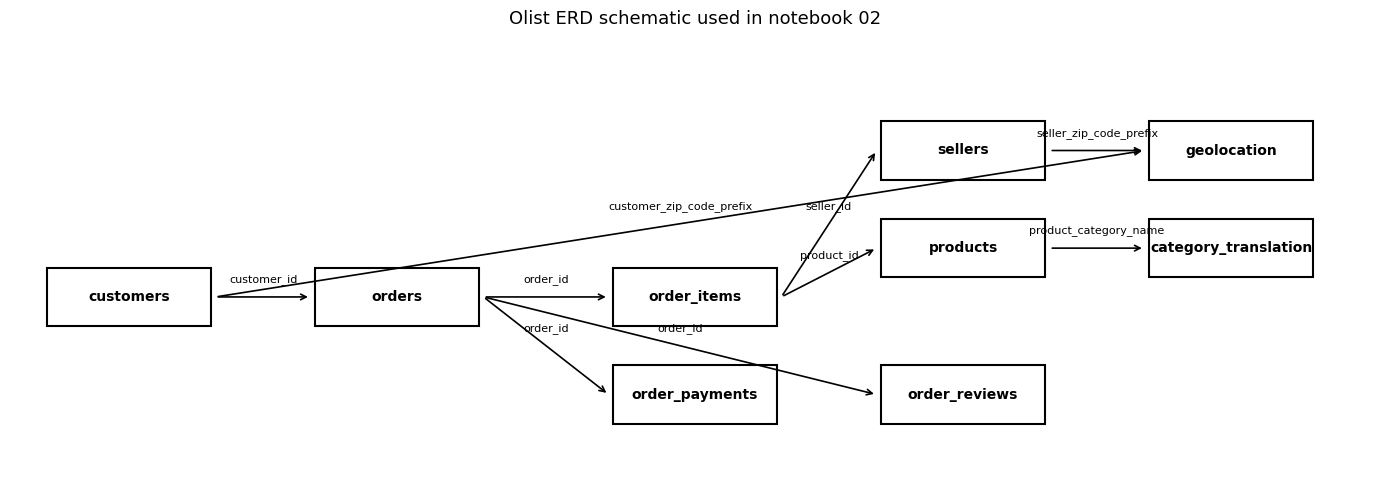

Đã lưu ERD schematic tại: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\data\processed\olist_erd_schematic.png


In [7]:
erd_nodes = {
    "customers": (0.8, 0.75),
    "orders": (2.6, 0.75),
    "order_items": (4.6, 0.75),
    "products": (6.4, 0.95),
    "category_translation": (8.2, 0.95),
    "order_payments": (4.6, 0.35),
    "order_reviews": (6.4, 0.35),
    "sellers": (6.4, 1.35),
    "geolocation": (8.2, 1.35),
}

erd_edges = [
    ("customers", "orders", "customer_id"),
    ("orders", "order_items", "order_id"),
    ("orders", "order_payments", "order_id"),
    ("orders", "order_reviews", "order_id"),
    ("order_items", "products", "product_id"),
    ("products", "category_translation", "product_category_name"),
    ("order_items", "sellers", "seller_id"),
    ("customers", "geolocation", "customer_zip_code_prefix"),
    ("sellers", "geolocation", "seller_zip_code_prefix"),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 9.2)
ax.set_ylim(0, 1.8)
ax.axis("off")

for name, (x, y) in erd_nodes.items():
    rect = plt.Rectangle((x - 0.55, y - 0.12), 1.1, 0.24, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y, name, ha="center", va="center", fontsize=10, fontweight="bold")

for left, right, label in erd_edges:
    x1, y1 = erd_nodes[left]
    x2, y2 = erd_nodes[right]
    ax.annotate(
        "",
        xy=(x2 - 0.58, y2),
        xytext=(x1 + 0.58, y1),
        arrowprops=dict(arrowstyle="->", lw=1.2),
    )
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.06, label, fontsize=8, ha="center")

ax.set_title("Olist ERD schematic used in notebook 02", fontsize=13, pad=12)
plt.tight_layout()

erd_schematic_path = PROCESSED_DIR / "olist_erd_schematic.png"
plt.savefig(erd_schematic_path, dpi=200, bbox_inches="tight")
plt.show()

print("Đã lưu ERD schematic tại:", erd_schematic_path)


## Cell 8 — Biểu đồ phân bố tối thiểu để bám rubric EDA

Cell này thêm 2 biểu đồ đơn giản nhưng quan trọng:

- phân bố `review_score`;
- phân bố `order_status`.

Mục tiêu:
- giúp file 02 có **evidence về distribution plots** ngay trong notebook;
- hỗ trợ chèn screenshot cho phần EDA/report mà không phải quay lại notebook khác.


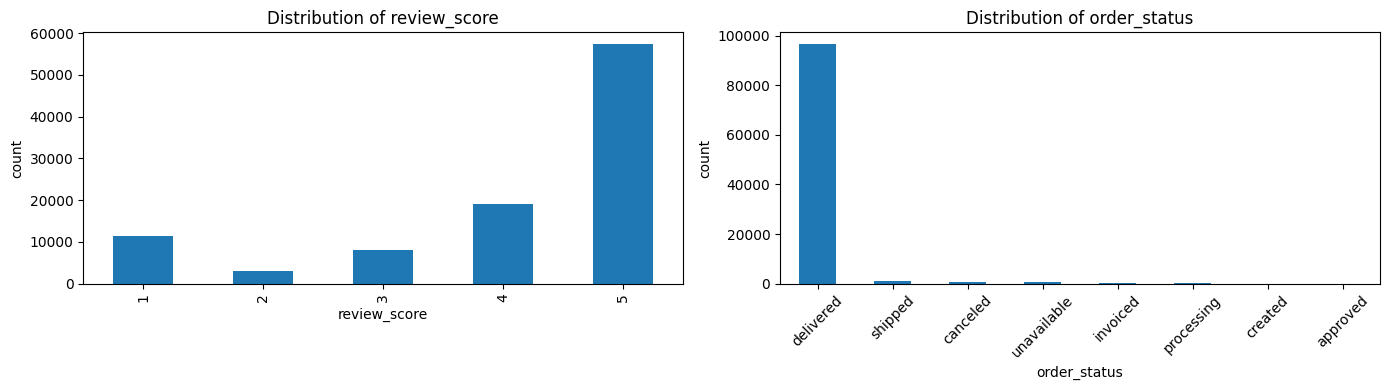

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

order_reviews_df["review_score"].value_counts(dropna=False).sort_index().plot(
    kind="bar", ax=axes[0], title="Distribution of review_score"
)
axes[0].set_xlabel("review_score")
axes[0].set_ylabel("count")

orders_df["order_status"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[1], title="Distribution of order_status"
)
axes[1].set_xlabel("order_status")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Cell 9 — Hàm tiện ích chuẩn hóa zip prefix và lấy mode an toàn

Cell này định nghĩa các helper dùng xuyên suốt notebook:

- `safe_mode`: lấy mode an toàn, có giá trị fallback nếu toàn null.
- `normalize_zip_prefix`: chuẩn hóa zip prefix về kiểu số nullable để join giữa `customers / sellers / geolocation` ổn định hơn.

Lý do:
- dữ liệu zip prefix thường bị đọc lẫn kiểu `int / float / string`;
- join geolocation theo zip prefix nếu không chuẩn hóa trước rất dễ lệch.


In [9]:
def safe_mode(series, default="unknown"):
    s = series.dropna()
    mode_vals = s.mode()
    return mode_vals.iloc[0] if not mode_vals.empty else default

def normalize_zip_prefix(series):
    normalized = pd.to_numeric(series, errors="coerce").astype("Int64")
    return normalized


## Cell 10 — Chuẩn hóa dtype thời gian và zip prefix

Cell này chuẩn hóa:
- toàn bộ cột thời gian quan trọng sang `datetime`;
- zip prefix của `customers`, `sellers`, `geolocation` sang `Int64`.

Đây là bước bắt buộc trước khi:
- tính feature thời gian/logistics;
- join geolocation theo zip prefix.


In [10]:
order_time_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in order_time_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

order_items_df["shipping_limit_date"] = pd.to_datetime(
    order_items_df["shipping_limit_date"], errors="coerce"
)

review_time_cols = ["review_creation_date", "review_answer_timestamp"]
for col in review_time_cols:
    order_reviews_df[col] = pd.to_datetime(order_reviews_df[col], errors="coerce")

customers_df["customer_zip_code_prefix"] = normalize_zip_prefix(customers_df["customer_zip_code_prefix"])
sellers_df["seller_zip_code_prefix"] = normalize_zip_prefix(sellers_df["seller_zip_code_prefix"])
geolocation_df["geolocation_zip_code_prefix"] = normalize_zip_prefix(geolocation_df["geolocation_zip_code_prefix"])

display(Markdown("### Dtype thời gian sau khi ép kiểu"))
display(orders_df[order_time_cols].dtypes)

display(Markdown("### Ví dụ zip prefix sau chuẩn hóa"))
display(pd.DataFrame({
    "customers_zip_dtype": [str(customers_df["customer_zip_code_prefix"].dtype)],
    "sellers_zip_dtype": [str(sellers_df["seller_zip_code_prefix"].dtype)],
    "geolocation_zip_dtype": [str(geolocation_df["geolocation_zip_code_prefix"].dtype)],
}))


### Dtype thời gian sau khi ép kiểu

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

### Ví dụ zip prefix sau chuẩn hóa

,customers_zip_dtype,sellers_zip_dtype,geolocation_zip_dtype
0,Int64,Int64,Int64


## Cell 11 — Kiểm tra duplicate và xử lý duplicate tối thiểu, an toàn

Chính sách của notebook này:
- **không drop duplicate hàng loạt** trên các bảng lõi nếu chưa có lý do khóa rõ ràng;
- chỉ `drop_duplicates()` cho `geolocation` vì bảng này có rất nhiều full-row duplicates và bản chất là bảng lookup vị trí.

Lý do:
- tránh làm mất record hợp lệ ở `order_reviews`, `order_payments`, `order_items`;
- vẫn làm sạch đủ cho geolocation aggregation.


In [11]:
geo_dup_before = geolocation_df.duplicated().sum()
geolocation_df = geolocation_df.drop_duplicates().copy()

dup_summary = pd.DataFrame({
    "table": ["customers", "geolocation", "order_items", "order_payments", "order_reviews", "orders", "products", "sellers"],
    "duplicate_full_rows_before_clean": [
        customers_df.duplicated().sum(),
        geo_dup_before,
        order_items_df.duplicated().sum(),
        order_payments_df.duplicated().sum(),
        order_reviews_df.duplicated().sum(),
        orders_df.duplicated().sum(),
        products_df.duplicated().sum(),
        sellers_df.duplicated().sum(),
    ]
})

display(dup_summary)

display(Markdown("### Geolocation sau khi drop duplicate"))
display(pd.DataFrame([{
    "rows_before": len(geolocation),
    "rows_after": len(geolocation_df),
    "rows_removed": len(geolocation) - len(geolocation_df),
}]))


,table,duplicate_full_rows_before_clean
0,customers,0
1,geolocation,261831
2,order_items,0
3,order_payments,0
4,order_reviews,0
5,orders,0
6,products,0
7,sellers,0


### Geolocation sau khi drop duplicate

,rows_before,rows_after,rows_removed
0,1000163,738332,261831


## Cell 12 — Tạo bảng geolocation aggregate theo zip prefix

Cell này gom `geolocation` về mức `zip_prefix` để tạo feature vị trí gọn và dễ join.

Đầu ra chính:
- `geo_by_zip`: trung bình latitude/longitude theo zip;
- city/state mode theo zip prefix.

Lý do dùng aggregate theo zip:
- `geolocation` có rất nhiều dòng cho cùng zip prefix;
- downstream modeling không cần toàn bộ granular geolocation raw.


In [12]:
geo_by_zip = (
    geolocation_df
    .dropna(subset=["geolocation_zip_code_prefix"])
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geo_lat_mean=("geolocation_lat", "mean"),
        geo_lng_mean=("geolocation_lng", "mean"),
        geo_city_mode=("geolocation_city", lambda x: safe_mode(x, default="unknown")),
        geo_state_mode=("geolocation_state", lambda x: safe_mode(x, default="unknown")),
        geo_record_count=("geolocation_lat", "size"),
    )
)

display(geo_by_zip.head())
print("geo_by_zip shape:", geo_by_zip.shape)


,geolocation_zip_code_prefix,geo_lat_mean,geo_lng_mean,geo_city_mode,geo_state_mode,geo_record_count
0,1001,-23.550227,-46.634039,sao paulo,SP,11
1,1002,-23.547657,-46.634991,sao paulo,SP,6
2,1003,-23.549000,-46.635582,sao paulo,SP,11
3,1004,-23.549829,-46.634792,sao paulo,SP,14
4,1005,-23.549547,-46.636406,sao paulo,SP,13


geo_by_zip shape: (19015, 6)


## Cell 13 — Chuẩn hóa danh mục sản phẩm sang tiếng Anh

Cell này merge `products` với `category_translation` để tạo `products_en`.

Ý nghĩa:
- giúp `main_category` nhất quán hơn;
- hỗ trợ classification/regression/FP-Growth/report dễ đọc hơn.


In [13]:
products_en = (
    products_df[["product_id", "product_category_name"]]
    .merge(category_translation_df, on="product_category_name", how="left")
    .copy()
)

products_en["product_category_name_english"] = (
    products_en["product_category_name_english"]
    .fillna(products_en["product_category_name"])
    .fillna("unknown")
    .astype(str)
)

display(products_en.head())


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## Cell 14 — Enrich `customers` và `sellers` bằng geolocation

Cell này là bước quan trọng để notebook **đi qua đủ 9 bảng** mà vẫn giữ grain cuối là **1 dòng = 1 order**:

- `customers_enriched`: customer info + customer geolocation theo zip;
- `sellers_enriched`: seller info + seller geolocation theo zip.

Như vậy:
- `geolocation` và `sellers` không bị bỏ rơi;
- feature geo/seller có thể được aggregate về order-level ở bước sau.


In [14]:
customers_enriched = (
    customers_df
    .merge(
        geo_by_zip.add_prefix("customer_").rename(columns={"customer_geolocation_zip_code_prefix": "customer_zip_code_prefix"}),
        on="customer_zip_code_prefix",
        how="left",
    )
    .copy()
)

sellers_enriched = (
    sellers_df
    .merge(
        geo_by_zip.add_prefix("seller_").rename(columns={"seller_geolocation_zip_code_prefix": "seller_zip_code_prefix"}),
        on="seller_zip_code_prefix",
        how="left",
    )
    .copy()
)

display(Markdown("### customers_enriched sample"))
display(customers_enriched.head())

display(Markdown("### sellers_enriched sample"))
display(sellers_enriched.head())


### customers_enriched sample

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_geo_lat_mean,customer_geo_lng_mean,customer_geo_city_mode,customer_geo_state_mode,customer_geo_record_count
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.499273,-47.396658,franca,SP,126.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.728396,-46.542250,sao bernardo do campo,SP,125.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531309,-46.656690,sao paulo,SP,34.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.500670,-46.186348,mogi das cruzes,SP,83.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975708,-47.143140,campinas,SP,131.0


### sellers_enriched sample

,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_geo_lat_mean,seller_geo_lng_mean,seller_geo_city_mode,seller_geo_state_mode,seller_geo_record_count
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,-22.893317,-47.060596,campinas,SP,58.0
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,-22.383375,-46.948142,mogi-guacu,SP,91.0
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,-22.909446,-43.180240,rio de janeiro,RJ,98.0
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,-23.657118,-46.612730,sao paulo,SP,60.0
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,-22.964546,-46.534214,braganca paulista,SP,108.0


## Cell 15 — Aggregate `order_items` về mức đơn hàng, có seller/product/category features

Cell này merge:
- `order_items`
- `products_en`
- `sellers_enriched`

rồi aggregate về `order_id` để tạo `items_agg`.

Các feature chính:
- số item / số sản phẩm / số seller;
- tổng giá, tổng phí ship, giá trung bình;
- danh mục chính;
- thông tin seller ở mức đơn hàng (`seller_state_mode`, `seller_city_mode`, tọa độ seller trung bình...`).

Đây là cell giúp merge **products + category_translation + sellers + geolocation** đi vào master ở dạng order-level an toàn.


In [15]:
items_tmp = (
    order_items_df
    .merge(
        products_en[["product_id", "product_category_name_english"]],
        on="product_id",
        how="left",
    )
    .merge(
        sellers_enriched[[
            "seller_id",
            "seller_city",
            "seller_state",
            "seller_geo_lat_mean",
            "seller_geo_lng_mean",
        ]],
        on="seller_id",
        how="left",
    )
    .copy()
)

items_tmp["product_category_name_english"] = (
    items_tmp["product_category_name_english"]
    .fillna("unknown")
    .astype(str)
)

items_agg = (
    items_tmp
    .groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        price_sum=("price", "sum"),
        freight_value_sum=("freight_value", "sum"),
        price_mean=("price", "mean"),
        main_category=("product_category_name_english", lambda x: safe_mode(x, default="unknown")),
        seller_city_mode=("seller_city", lambda x: safe_mode(x, default="unknown")),
        seller_state_mode=("seller_state", lambda x: safe_mode(x, default="unknown")),
        seller_geo_lat_mean=("seller_geo_lat_mean", "mean"),
        seller_geo_lng_mean=("seller_geo_lng_mean", "mean"),
    )
)

display(items_agg.head())
print("items_agg shape:", items_agg.shape)


,order_id,item_count,unique_products,unique_sellers,price_sum,freight_value_sum,price_mean,main_category,seller_city_mode,seller_state_mode,seller_geo_lat_mean,seller_geo_lng_mean
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,58.90,cool_stuff,volta redonda,SP,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,239.90,pet_shop,sao paulo,SP,-23.565754,-46.519097
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,199.00,furniture_decor,borda da mata,MG,-22.262802,-46.170735
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,12.99,perfumery,franca,SP,-20.553651,-47.387145
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,199.90,garden_tools,loanda,PR,-22.929583,-53.135750


items_agg shape: (98666, 12)


## Cell 16 — Aggregate `order_payments` về mức đơn hàng

Cell này gom payment về `order_id`.

Chiến lược:
- `payment_value_sum`: tổng giá trị thanh toán;
- `payment_installments_max`: số installment lớn nhất trong order;
- `payment_type_mode`: loại thanh toán phổ biến nhất.

Cách này giữ được signal tài chính quan trọng mà không làm nổ dòng khi merge.


In [16]:
payments_agg = (
    order_payments_df
    .groupby("order_id", as_index=False)
    .agg(
        payment_sequential_max=("payment_sequential", "max"),
        payment_installments_max=("payment_installments", "max"),
        payment_value_sum=("payment_value", "sum"),
        payment_type_mode=("payment_type", lambda x: safe_mode(x, default="unknown")),
    )
)

display(payments_agg.head())
print("payments_agg shape:", payments_agg.shape)


,order_id,payment_sequential_max,payment_installments_max,payment_value_sum,payment_type_mode
0,00010242fe8c5a6d1ba2dd792cb16214,1,2,72.19,credit_card
1,00018f77f2f0320c557190d7a144bdd3,1,3,259.83,credit_card
2,000229ec398224ef6ca0657da4fc703e,1,5,216.87,credit_card
3,00024acbcdf0a6daa1e931b038114c75,1,2,25.78,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,3,218.04,credit_card


payments_agg shape: (99440, 5)


## Cell 17 — Aggregate `order_reviews` về mức đơn hàng

Cell này chuẩn hóa review text và gom review về `order_id`.

Feature sinh ra:
- `review_count`
- `review_score`
- `review_comment_message`
- `review_comment_length`
- `has_comment`
- `review_response_hours`

Chính sách:
- sort theo thời gian trước khi lấy `last` để giữ record review cuối cùng một cách có chủ đích;
- giữ text review cho TF-IDF ở bước sau.


In [17]:
order_reviews_df["review_comment_message"] = (
    order_reviews_df["review_comment_message"]
    .fillna("")
    .astype(str)
)

order_reviews_df["review_comment_length"] = order_reviews_df["review_comment_message"].str.len()
order_reviews_df["has_comment"] = (order_reviews_df["review_comment_length"] > 0).astype("Int64")
order_reviews_df["review_response_hours"] = (
    order_reviews_df["review_answer_timestamp"] - order_reviews_df["review_creation_date"]
).dt.total_seconds() / 3600

sort_cols = [c for c in ["order_id", "review_creation_date", "review_answer_timestamp"] if c in order_reviews_df.columns]
order_reviews_df = order_reviews_df.sort_values(sort_cols, na_position="last")

reviews_agg = (
    order_reviews_df
    .groupby("order_id", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        review_score=("review_score", "last"),
        review_comment_message=("review_comment_message", "last"),
        review_comment_length=("review_comment_length", "last"),
        has_comment=("has_comment", "max"),
        review_response_hours=("review_response_hours", "last"),
    )
)

display(reviews_agg.head())
print("reviews_agg shape:", reviews_agg.shape)


,order_id,review_count,review_score,review_comment_message,review_comment_length,has_comment,review_response_hours
0,00010242fe8c5a6d1ba2dd792cb16214,1,5,"Perfeito, produto entregue antes do combinado.",46,1,34.950833
1,00018f77f2f0320c557190d7a144bdd3,1,4,,0,0,59.570278
2,000229ec398224ef6ca0657da4fc703e,1,5,Chegou antes do prazo previsto e o produto sur...,90,1,16.108611
3,00024acbcdf0a6daa1e931b038114c75,1,4,,0,0,16.650278
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,5,Gostei pois veio no prazo determinado .,39,1,34.916389


reviews_agg shape: (98673, 7)


## Cell 18 — Merge thành `orders_base` ở grain 1 dòng = 1 order

Thứ tự merge:
1. `orders`
2. `customers_enriched` theo `customer_id` (`left`)
3. `items_agg` theo `order_id` (`left`)
4. `payments_agg` theo `order_id` (`left`)
5. `reviews_agg` theo `order_id` (`left`)

Kết quả:
- vẫn giữ grain order-level;
- đi qua đủ 9 bảng vì:
  - `customers_enriched` đã mang geolocation;
  - `items_agg` đã mang products/category_translation/sellers/geolocation.


In [18]:
orders_base = (
    orders_df
    .merge(
        customers_enriched[[
            "customer_id",
            "customer_unique_id",
            "customer_city",
            "customer_state",
            "customer_zip_code_prefix",
            "customer_geo_lat_mean",
            "customer_geo_lng_mean",
        ]],
        on="customer_id",
        how="left",
    )
    .merge(items_agg, on="order_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_agg, on="order_id", how="left")
)

display(orders_base.head())
print("orders_base shape:", orders_base.shape)
print("orders_base unique order_id:", orders_base["order_id"].nunique())
print("orders_base order_id is_unique:", orders_base["order_id"].is_unique)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,payment_sequential_max,payment_installments_max,payment_value_sum,payment_type_mode,review_count,review_score,review_comment_message,review_comment_length,has_comment,review_response_hours
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,3.0,1.0,38.71,voucher,1.0,4.0,"Não testei o produto ainda, mas ele veio corre...",170.0,1,27.730000
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,1.0,1.0,141.46,boleto,1.0,4.0,Muito bom o produto.,20.0,1,18.630556
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,1.0,3.0,179.12,credit_card,1.0,5.0,,0.0,0,115.132778
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,1.0,1.0,72.20,credit_card,1.0,5.0,O produto foi exatamente o que eu esperava e e...,105.0,1,67.366111
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,1.0,1.0,28.62,credit_card,1.0,5.0,,0.0,0,37.047500


orders_base shape: (99441, 35)
orders_base unique order_id: 99441
orders_base order_id is_unique: True


## Cell 19 — Join audit, source lineage và kiểm tra grain sau merge

Cell này không chỉ liệt kê **4 bước merge cuối** vào `orders_base`, mà còn mở rộng thêm **source lineage đi qua đủ 9 bảng raw**.

Mục tiêu:
- chứng minh bảng nào tham gia ở bước nào;
- merge key là gì;
- join type là gì;
- intermediate output nào được tạo ra trước khi lên `orders_base`;
- output cuối có còn đúng **grain 1 dòng = 1 order** hay không.

Cell này là minh chứng trực tiếp cho phần **Join/Merge bảng** trong rubric và đủ chi tiết để dùng lại khi viết báo cáo.


In [19]:
source_lineage_df = pd.DataFrame([
    {
        "lineage_step": 1,
        "source_table": "customers_df",
        "join_key": "customer_zip_code_prefix",
        "join_type": "left",
        "intermediate_output": "customers_enriched",
        "grain_before": "1 row = 1 customer",
        "grain_after": "1 row = 1 customer",
        "role_in_master_dataset": "Bổ sung customer location/state/city",
    },
    {
        "lineage_step": 2,
        "source_table": "geolocation_df",
        "join_key": "geolocation_zip_code_prefix -> *_zip_code_prefix",
        "join_type": "aggregate then left join",
        "intermediate_output": "geo_by_zip",
        "grain_before": "many rows per zip prefix",
        "grain_after": "1 row = 1 zip prefix",
        "role_in_master_dataset": "Chuẩn hóa địa lý để enrich customers/sellers",
    },
    {
        "lineage_step": 3,
        "source_table": "products_df",
        "join_key": "product_id",
        "join_type": "left",
        "intermediate_output": "products_en",
        "grain_before": "1 row = 1 product",
        "grain_after": "1 row = 1 product",
        "role_in_master_dataset": "Giữ thông tin product/category",
    },
    {
        "lineage_step": 4,
        "source_table": "category_translation_df",
        "join_key": "product_category_name",
        "join_type": "left",
        "intermediate_output": "products_en",
        "grain_before": "1 row = 1 category mapping",
        "grain_after": "1 row = 1 product (sau merge vào products)",
        "role_in_master_dataset": "Dịch category sang tiếng Anh",
    },
    {
        "lineage_step": 5,
        "source_table": "sellers_df",
        "join_key": "seller_zip_code_prefix",
        "join_type": "left",
        "intermediate_output": "sellers_enriched",
        "grain_before": "1 row = 1 seller",
        "grain_after": "1 row = 1 seller",
        "role_in_master_dataset": "Bổ sung seller location/state/city",
    },
    {
        "lineage_step": 6,
        "source_table": "order_items_df",
        "join_key": "order_id / product_id / seller_id",
        "join_type": "left then groupby(order_id)",
        "intermediate_output": "items_agg",
        "grain_before": "n rows per order",
        "grain_after": "1 row = 1 order",
        "role_in_master_dataset": "Sinh item/basket/category/seller features",
    },
    {
        "lineage_step": 7,
        "source_table": "order_payments_df",
        "join_key": "order_id",
        "join_type": "groupby(order_id)",
        "intermediate_output": "payments_agg",
        "grain_before": "n rows per order",
        "grain_after": "1 row = 1 order",
        "role_in_master_dataset": "Sinh payment features",
    },
    {
        "lineage_step": 8,
        "source_table": "order_reviews_df",
        "join_key": "order_id",
        "join_type": "groupby(order_id)",
        "intermediate_output": "reviews_agg",
        "grain_before": "n rows per order / review",
        "grain_after": "1 row = 1 order",
        "role_in_master_dataset": "Sinh review/text/review-response features",
    },
    {
        "lineage_step": 9,
        "source_table": "orders_df",
        "join_key": "order_id / customer_id",
        "join_type": "left",
        "intermediate_output": "orders_base",
        "grain_before": "1 row = 1 order",
        "grain_after": "1 row = 1 order",
        "role_in_master_dataset": "Bảng xương sống để ghép toàn bộ artifact order-level",
    },
])

join_audit_df = pd.DataFrame([
    {"step": 1, "left_table": "orders_df", "right_table": "customers_enriched", "join_key": "customer_id", "how": "left", "output_name": "orders + customers"},
    {"step": 2, "left_table": "orders + customers", "right_table": "items_agg", "join_key": "order_id", "how": "left", "output_name": "… + items_agg"},
    {"step": 3, "left_table": "… + items_agg", "right_table": "payments_agg", "join_key": "order_id", "how": "left", "output_name": "… + payments_agg"},
    {"step": 4, "left_table": "… + payments_agg", "right_table": "reviews_agg", "join_key": "order_id", "how": "left", "output_name": "orders_base"},
])

grain_audit_df = pd.DataFrame([{
    "orders_rows": len(orders_df),
    "orders_unique_order_id": orders_df["order_id"].nunique(),
    "orders_base_rows": len(orders_base),
    "orders_base_unique_order_id": orders_base["order_id"].nunique(),
    "orders_base_order_id_is_unique": bool(orders_base["order_id"].is_unique),
    "grain_definition": "1 row = 1 order",
}])

display(Markdown("### Source lineage (đi qua đủ 9 bảng raw)"))
display(source_lineage_df)

display(Markdown("### Final merge audit into orders_base"))
display(join_audit_df)

display(Markdown("### Grain audit"))
display(grain_audit_df)


### Source lineage (đi qua đủ 9 bảng raw)

,lineage_step,source_table,join_key,join_type,intermediate_output,grain_before,grain_after,role_in_master_dataset
0,1,customers_df,customer_zip_code_prefix,left,customers_enriched,1 row = 1 customer,1 row = 1 customer,Bổ sung customer location/state/city
1,2,geolocation_df,geolocation_zip_code_prefix -> *_zip_code_prefix,aggregate then left join,geo_by_zip,many rows per zip prefix,1 row = 1 zip prefix,Chuẩn hóa địa lý để enrich customers/sellers
2,3,products_df,product_id,left,products_en,1 row = 1 product,1 row = 1 product,Giữ thông tin product/category
3,4,category_translation_df,product_category_name,left,products_en,1 row = 1 category mapping,1 row = 1 product (sau merge vào products),Dịch category sang tiếng Anh
4,5,sellers_df,seller_zip_code_prefix,left,sellers_enriched,1 row = 1 seller,1 row = 1 seller,Bổ sung seller location/state/city
5,6,order_items_df,order_id / product_id / seller_id,left then groupby(order_id),items_agg,n rows per order,1 row = 1 order,Sinh item/basket/category/seller features
6,7,order_payments_df,order_id,groupby(order_id),payments_agg,n rows per order,1 row = 1 order,Sinh payment features
7,8,order_reviews_df,order_id,groupby(order_id),reviews_agg,n rows per order / review,1 row = 1 order,Sinh review/text/review-response features
8,9,orders_df,order_id / customer_id,left,orders_base,1 row = 1 order,1 row = 1 order,Bảng xương sống để ghép toàn bộ artifact order...


### Final merge audit into orders_base

,step,left_table,right_table,join_key,how,output_name
0,1,orders_df,customers_enriched,customer_id,left,orders + customers
1,2,orders + customers,items_agg,order_id,left,… + items_agg
2,3,… + items_agg,payments_agg,order_id,left,… + payments_agg
3,4,… + payments_agg,reviews_agg,order_id,left,orders_base


### Grain audit

,orders_rows,orders_unique_order_id,orders_base_rows,orders_base_unique_order_id,orders_base_order_id_is_unique,grain_definition
0,99441,99441,99441,99441,True,1 row = 1 order


## Cell 20 — Kiểm tra missing values sau merge và tách riêng raw-vs-master missing

Cell này làm 2 việc:

1. Thống kê missing ở `orders_base` sau khi merge để phục vụ quyết định fill/giữ NaN.
2. So sánh riêng `review_comment_message` ở:
   - raw `order_reviews_df`
   - master `orders_base`

Lý do phải tách riêng:
- phần báo cáo thường nhắc `review_comment_message` có tỷ lệ null rất cao ở **raw review table**;
- nhưng sau khi aggregate về order-level, ý nghĩa missing thay đổi;
- nếu không tách rõ, phần báo cáo rất dễ tự mâu thuẫn.


In [20]:
missing_after_merge = (
    orders_base.isnull().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_after_merge["missing_pct"] = (
    missing_after_merge["missing_count"] / len(orders_base) * 100
).round(2)

missing_after_merge = missing_after_merge.sort_values("missing_pct", ascending=False).reset_index(drop=True)

raw_review_comment_missing_pct = round(order_reviews["review_comment_message"].isnull().mean() * 100, 2)
master_review_comment_missing_pct = round(orders_base["review_comment_message"].isnull().mean() * 100, 2)

review_comment_missing_compare_df = pd.DataFrame([
    {
        "dataset_level": "raw_order_reviews",
        "column": "review_comment_message",
        "rows": len(order_reviews),
        "missing_pct": raw_review_comment_missing_pct,
        "meaning_of_missing": "Review record tồn tại nhưng comment text trống / null",
    },
    {
        "dataset_level": "orders_base_after_merge",
        "column": "review_comment_message",
        "rows": len(orders_base),
        "missing_pct": master_review_comment_missing_pct,
        "meaning_of_missing": "Order-level record chưa có review/comment sau khi aggregate + merge",
    },
])

display(Markdown("### Missing values after merge"))
display(missing_after_merge.head(25))

display(Markdown("### Raw vs master missing comparison for review text"))
display(review_comment_missing_compare_df)


### Missing values after merge

,column,missing_count,missing_pct
0,order_delivered_customer_date,2965,2.98
1,order_delivered_carrier_date,1783,1.79
2,seller_geo_lng_mean,991,1.00
3,seller_geo_lat_mean,991,1.00
4,unique_sellers,775,0.78
5,unique_products,775,0.78
6,item_count,775,0.78
7,main_category,775,0.78
8,seller_city_mode,775,0.78
9,seller_state_mode,775,0.78


### Raw vs master missing comparison for review text

,dataset_level,column,rows,missing_pct,meaning_of_missing
0,raw_order_reviews,review_comment_message,99224,58.70,Review record tồn tại nhưng comment text trống...
1,orders_base_after_merge,review_comment_message,99441,0.77,Order-level record chưa có review/comment sau ...


## Cell 21 — Bảng chiến lược xử lý missing values theo từng cột

Cell này mở rộng bảng chiến lược để minh họa rõ hơn:

- **cột nào fill ngay tại preprocessing stage**;
- **cột nào giữ NaN** để downstream pipeline tự impute;
- **lý do kỹ thuật** cho từng lựa chọn;
- **cột numeric/time/location nào được xem là model-sensitive**.

Mục tiêu là bám sát rubric ở mức chấm khó: không chỉ nói nguyên tắc chung, mà phải cho thấy chiến lược đủ chi tiết theo từng nhóm/cột quan trọng.


In [21]:
missing_rate_map = dict(
    zip(
        missing_after_merge["column"].tolist(),
        missing_after_merge["missing_pct"].tolist(),
    )
)

missing_strategy_rows = [
    {
        "column": "review_comment_message",
        "missing_pct": missing_rate_map.get("review_comment_message", 0.0),
        "strategy": "fillna('')",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "dùng trực tiếp cho TF-IDF / text analysis",
        "reason": "Giữ dòng dữ liệu và chuẩn hóa text field cho NLP branch",
    },
    {
        "column": "main_category",
        "missing_pct": missing_rate_map.get("main_category", 0.0),
        "strategy": "fillna('unknown')",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "dùng trực tiếp trong categorical modeling",
        "reason": "Thiếu category vẫn giữ được order và tránh NaN categorical",
    },
    {
        "column": "payment_type_mode",
        "missing_pct": missing_rate_map.get("payment_type_mode", 0.0),
        "strategy": "fillna('unknown')",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "dùng trực tiếp trong categorical modeling",
        "reason": "Ổn định hóa feature thanh toán dạng category",
    },
    {
        "column": "customer_city",
        "missing_pct": missing_rate_map.get("customer_city", 0.0),
        "strategy": "fillna('unknown')",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "dùng trực tiếp trong categorical modeling",
        "reason": "Giữ order-level record dù thiếu chi tiết địa lý",
    },
    {
        "column": "customer_state",
        "missing_pct": missing_rate_map.get("customer_state", 0.0),
        "strategy": "fillna('unknown')",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "dùng trực tiếp trong categorical modeling",
        "reason": "Giữ feature vùng miền quan trọng cho hành vi mua sắm",
    },
    {
        "column": "seller_city_mode",
        "missing_pct": missing_rate_map.get("seller_city_mode", 0.0),
        "strategy": "fillna('unknown')",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "dùng trực tiếp trong categorical modeling",
        "reason": "Thiếu city của seller không nên làm mất order-level sample",
    },
    {
        "column": "seller_state_mode",
        "missing_pct": missing_rate_map.get("seller_state_mode", 0.0),
        "strategy": "fillna('unknown')",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "dùng trực tiếp trong categorical modeling",
        "reason": "Thiếu state của seller không nên làm mất order-level sample",
    },
    {
        "column": "has_comment",
        "missing_pct": missing_rate_map.get("has_comment", 0.0),
        "strategy": "fillna(0)",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "coerce về binary/comment flag",
        "reason": "Null ở đây tương đương không có comment",
    },
    {
        "column": "review_count",
        "missing_pct": missing_rate_map.get("review_count", 0.0),
        "strategy": "fillna(0)",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "được dùng như count feature",
        "reason": "Không có review record thì số review = 0",
    },
    {
        "column": "item_count",
        "missing_pct": missing_rate_map.get("item_count", 0.0),
        "strategy": "keep NaN",
        "applied_in_this_notebook": "no",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Giữ nguyên giá trị thiếu để downstream pipeline tự quyết định imputation nhất quán",
    },
    {
        "column": "unique_products",
        "missing_pct": missing_rate_map.get("unique_products", 0.0),
        "strategy": "keep NaN",
        "applied_in_this_notebook": "no",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Tránh áp median-fill quá sớm trên feature basket-level",
    },
    {
        "column": "unique_sellers",
        "missing_pct": missing_rate_map.get("unique_sellers", 0.0),
        "strategy": "keep NaN",
        "applied_in_this_notebook": "no",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Giữ độ trung thực dữ liệu gốc trước model stage",
    },
    {
        "column": "approval_time_hours",
        "missing_pct": np.nan,
        "strategy": "set invalid/negative -> NaN; otherwise keep numeric",
        "applied_in_this_notebook": "yes (ở Cell 24 cho invalid durations)",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Duration âm/bất thường phải chuyển NaN; phần còn lại để downstream imputer xử lý",
    },
    {
        "column": "purchase_to_carrier_days",
        "missing_pct": np.nan,
        "strategy": "set invalid/negative -> NaN; otherwise keep numeric",
        "applied_in_this_notebook": "yes (ở Cell 24 cho invalid durations)",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Duration logistic có thể thiếu ở order chưa hoàn tất hoặc timestamp lỗi",
    },
    {
        "column": "delivery_time_days",
        "missing_pct": np.nan,
        "strategy": "set invalid/negative -> NaN; otherwise keep numeric",
        "applied_in_this_notebook": "yes (ở Cell 24 cho invalid durations)",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Không ép fill tại preprocessing để tránh làm sai tín hiệu vận chuyển",
    },
    {
        "column": "shipping_time_days",
        "missing_pct": np.nan,
        "strategy": "set invalid/negative -> NaN; otherwise keep numeric",
        "applied_in_this_notebook": "yes (ở Cell 24 cho invalid durations)",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Cột duration mang tính model-sensitive nên không fill cứng ở đây",
    },
    {
        "column": "estimated_vs_actual_delay_days",
        "missing_pct": np.nan,
        "strategy": "keep NaN when delivery timestamps missing",
        "applied_in_this_notebook": "yes",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Giữ phân biệt giữa 'chưa giao/không đủ timestamp' và giá trị delay thực",
    },
    {
        "column": "review_response_hours",
        "missing_pct": missing_rate_map.get("review_response_hours", 0.0),
        "strategy": "keep NaN",
        "applied_in_this_notebook": "no",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Phản hồi review không tồn tại ở order không có review; giữ NaN có nghĩa hơn fill cứng",
    },
    {
        "column": "customer_geo_lat_mean",
        "missing_pct": missing_rate_map.get("customer_geo_lat_mean", 0.0),
        "strategy": "keep NaN",
        "applied_in_this_notebook": "no",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Geolocation thiếu do zip không map được; để downstream imputer xử lý đồng nhất",
    },
    {
        "column": "customer_geo_lng_mean",
        "missing_pct": missing_rate_map.get("customer_geo_lng_mean", 0.0),
        "strategy": "keep NaN",
        "applied_in_this_notebook": "no",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Tương tự latitude; không median-fill ngay trong notebook preprocessing",
    },
    {
        "column": "seller_geo_lat_mean",
        "missing_pct": missing_rate_map.get("seller_geo_lat_mean", 0.0),
        "strategy": "keep NaN",
        "applied_in_this_notebook": "no",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Tránh làm mất dấu hiệu seller geolocation thiếu thật",
    },
    {
        "column": "seller_geo_lng_mean",
        "missing_pct": missing_rate_map.get("seller_geo_lng_mean", 0.0),
        "strategy": "keep NaN",
        "applied_in_this_notebook": "no",
        "downstream_handling": "SimpleImputer(strategy='median') trong model pipeline",
        "reason": "Tránh fill cưỡng bức khi bản chất là thiếu map geo theo zip",
    },
]

missing_strategy_df = pd.DataFrame(missing_strategy_rows)
display(missing_strategy_df)


,column,missing_pct,strategy,applied_in_this_notebook,downstream_handling,reason
0,review_comment_message,0.77,fillna(''),yes,dùng trực tiếp cho TF-IDF / text analysis,Giữ dòng dữ liệu và chuẩn hóa text field cho N...
1,main_category,0.78,fillna('unknown'),yes,dùng trực tiếp trong categorical modeling,Thiếu category vẫn giữ được order và tránh NaN...
2,payment_type_mode,0.00,fillna('unknown'),yes,dùng trực tiếp trong categorical modeling,Ổn định hóa feature thanh toán dạng category
3,customer_city,0.00,fillna('unknown'),yes,dùng trực tiếp trong categorical modeling,Giữ order-level record dù thiếu chi tiết địa lý
4,customer_state,0.00,fillna('unknown'),yes,dùng trực tiếp trong categorical modeling,Giữ feature vùng miền quan trọng cho hành vi m...
5,seller_city_mode,0.78,fillna('unknown'),yes,dùng trực tiếp trong categorical modeling,Thiếu city của seller không nên làm mất order-...
6,seller_state_mode,0.78,fillna('unknown'),yes,dùng trực tiếp trong categorical modeling,Thiếu state của seller không nên làm mất order...
7,has_comment,0.77,fillna(0),yes,coerce về binary/comment flag,Null ở đây tương đương không có comment
8,review_count,0.77,fillna(0),yes,được dùng như count feature,Không có review record thì số review = 0
9,item_count,0.78,keep NaN,no,SimpleImputer(strategy='median') trong model p...,Giữ nguyên giá trị thiếu để downstream pipelin...


## Cell 22 — Áp dụng xử lý missing values cơ bản, có chủ đích

Cell này chỉ fill những cột **business-safe** và **semantically clear** ngay ở preprocessing stage.

Nguyên tắc:
- text/comment categorical thiếu nhưng vẫn hợp lệ về mặt nghiệp vụ → fill ngay;
- count/binary mà null đồng nghĩa với không có sự kiện → fill `0`;
- numeric/time/location nhạy với mô hình → giữ `NaN` để downstream pipeline tự impute nhất quán.

Cách làm này giúp notebook 02 vẫn sạch dữ liệu, nhưng không áp đặt một chiến lược imputation quá sớm lên mọi bài toán downstream.


In [22]:
orders_base["review_comment_message"] = orders_base["review_comment_message"].fillna("")

categorical_fill_unknown = [
    "main_category",
    "payment_type_mode",
    "customer_city",
    "customer_state",
    "seller_city_mode",
    "seller_state_mode",
]
for col in categorical_fill_unknown:
    if col in orders_base.columns:
        orders_base[col] = orders_base[col].fillna("unknown")

for col in ["has_comment", "review_count"]:
    if col in orders_base.columns:
        orders_base[col] = orders_base[col].fillna(0)

display(orders_base[categorical_fill_unknown + ["has_comment", "review_count"]].head())


,main_category,payment_type_mode,customer_city,customer_state,seller_city_mode,seller_state_mode,has_comment,review_count
0,housewares,voucher,sao paulo,SP,maua,SP,1,1.0
1,perfumery,boleto,barreiras,BA,belo horizonte,SP,1,1.0
2,auto,credit_card,vianopolis,GO,guariba,SP,0,1.0
3,pet_shop,credit_card,sao goncalo do amarante,RN,belo horizonte,MG,1,1.0
4,stationery,credit_card,santo andre,SP,mogi das cruzes,SP,0,1.0


## Cell 23 — Feature engineering thời gian, logistics và basket-level

Cell này sinh các feature dẫn xuất dùng lại cho nhiều notebook:

- `approval_time_hours`
- `purchase_to_carrier_days`
- `delivery_time_days`
- `shipping_time_days`
- `delivery_delay_days`
- `basket_value`
- các time parts: year / month / day / hour / dayofweek / period
- `is_late_delivery`
- `review_label` (binary) để downstream notebooks có thể dùng lại nếu muốn

Lưu ý:
- `review_label` chỉ là cột bổ sung, **không thay thế** `review_score`.


In [23]:
orders_base["approval_time_hours"] = (
    orders_base["order_approved_at"] - orders_base["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders_base["purchase_to_carrier_days"] = (
    orders_base["order_delivered_carrier_date"] - orders_base["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_base["delivery_time_days"] = (
    orders_base["order_delivered_customer_date"] - orders_base["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_base["shipping_time_days"] = (
    orders_base["order_delivered_customer_date"] - orders_base["order_delivered_carrier_date"]
).dt.total_seconds() / 86400

orders_base["delivery_delay_days"] = (
    orders_base["order_delivered_customer_date"] - orders_base["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders_base["basket_value"] = orders_base["price_sum"] + orders_base["freight_value_sum"]

orders_base["purchase_year"] = orders_base["order_purchase_timestamp"].dt.year
orders_base["purchase_month"] = orders_base["order_purchase_timestamp"].dt.month
orders_base["purchase_day"] = orders_base["order_purchase_timestamp"].dt.day
orders_base["purchase_hour"] = orders_base["order_purchase_timestamp"].dt.hour
orders_base["purchase_dayofweek"] = orders_base["order_purchase_timestamp"].dt.dayofweek
orders_base["purchase_month_period"] = orders_base["order_purchase_timestamp"].dt.to_period("M").astype(str)

orders_base["is_late_delivery"] = pd.Series(pd.NA, index=orders_base.index, dtype="Int64")
mask_delivered = orders_base["order_status"] == "delivered"
orders_base.loc[mask_delivered, "is_late_delivery"] = (
    orders_base.loc[mask_delivered, "delivery_delay_days"] > 0
).astype("Int64")

orders_base["review_label"] = pd.Series(pd.NA, index=orders_base.index, dtype="Int64")
mask_valid_review = orders_base["review_score"].notna()
orders_base.loc[mask_valid_review, "review_label"] = (
    pd.to_numeric(orders_base.loc[mask_valid_review, "review_score"], errors="coerce") >= 4
).astype("Int64")


## Cell 24 — Làm sạch duration âm / bất thường và tạo cờ kiểm tra thời gian

Cell này xử lý các duration không hợp lệ:
- giá trị âm ở các biến duration → set `NaN`;
- tạo các cờ issue để hỗ trợ QA/report.

Lý do:
- duration âm thường là lỗi timestamp hoặc dữ liệu chưa hoàn tất;
- thay vì sửa đoán mò, notebook giữ `NaN` và ghi nhận flag.


In [24]:
duration_cols = [
    "approval_time_hours",
    "purchase_to_carrier_days",
    "delivery_time_days",
    "shipping_time_days",
]

for col in duration_cols:
    orders_base.loc[orders_base[col] < 0, col] = np.nan

orders_base.loc[orders_base["review_response_hours"] < 0, "review_response_hours"] = np.nan

orders_base["time_issue_approval_before_purchase"] = (
    orders_base["order_approved_at"] < orders_base["order_purchase_timestamp"]
)

orders_base["time_issue_carrier_before_purchase"] = (
    orders_base["order_delivered_carrier_date"] < orders_base["order_purchase_timestamp"]
)

orders_base["time_issue_customer_before_carrier"] = (
    orders_base["order_delivered_customer_date"] < orders_base["order_delivered_carrier_date"]
)

display(orders_base[duration_cols + [
    "review_response_hours",
    "time_issue_approval_before_purchase",
    "time_issue_carrier_before_purchase",
    "time_issue_customer_before_carrier",
]].head())


,approval_time_hours,purchase_to_carrier_days,delivery_time_days,shipping_time_days,review_response_hours,time_issue_approval_before_purchase,time_issue_carrier_before_purchase,time_issue_customer_before_carrier
0,0.178333,2.373924,8.436574,6.062650,27.730000,False,False,False
1,30.713889,1.742627,13.782037,12.039410,18.630556,False,False,False
2,0.276111,0.216100,9.394213,9.178113,115.132778,False,False,False
3,0.298056,3.758252,13.208750,9.450498,67.366111,False,False,False
4,1.030556,0.936053,2.873877,1.937824,37.047500,False,False,False


## Cell 25 — Chốt `orders_base_final` và snapshot schema

Cell này tạo artifact lõi `orders_base_final`.

Yêu cầu tương thích:
- giữ nguyên các cột lõi mà notebook 03 / 04 / 05 / 08 đang dùng;
- chỉ bổ sung cột mới, không xóa cột cũ.


In [25]:
orders_base_final = orders_base.copy()

display(Markdown("### orders_base_final sample"))
display(orders_base_final.head())

print("orders_base_final shape:", orders_base_final.shape)
print("Unique orders:", orders_base_final["order_id"].nunique())

orders_base_schema_df = pd.DataFrame({
    "column": orders_base_final.columns,
    "dtype": orders_base_final.dtypes.astype(str).values,
    "missing_count": orders_base_final.isnull().sum().values,
    "missing_pct": (orders_base_final.isnull().mean() * 100).round(2).values,
})

orders_base_final_schema_payload = {
    "dataset_name": "orders_base_final",
    "grain_definition": "1 row = 1 order",
    "n_rows": int(len(orders_base_final)),
    "n_cols": int(orders_base_final.shape[1]),
    "columns": orders_base_final.columns.tolist(),
    "dtypes": {col: str(dtype) for col, dtype in orders_base_final.dtypes.items()},
}

display(Markdown("### orders_base_final schema summary"))
display(orders_base_schema_df.head(30))


### orders_base_final sample

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,purchase_month,purchase_day,purchase_hour,purchase_dayofweek,purchase_month_period,is_late_delivery,review_label,time_issue_approval_before_purchase,time_issue_carrier_before_purchase,time_issue_customer_before_carrier
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,10,2,10,0,2017-10,0,1,False,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,7,24,20,1,2018-07,0,1,False,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,8,8,8,2,2018-08,0,1,False,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,11,18,19,5,2017-11,0,1,False,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,2,13,21,1,2018-02,0,1,False,False,False


orders_base_final shape: (99441, 52)
Unique orders: 99441


### orders_base_final schema summary

,column,dtype,missing_count,missing_pct
0,order_id,object,0,0.00
1,customer_id,object,0,0.00
2,order_status,object,0,0.00
3,order_purchase_timestamp,datetime64[ns],0,0.00
4,order_approved_at,datetime64[ns],160,0.16
5,order_delivered_carrier_date,datetime64[ns],1783,1.79
6,order_delivered_customer_date,datetime64[ns],2965,2.98
7,order_estimated_delivery_date,datetime64[ns],0,0.00
8,customer_unique_id,object,0,0.00
9,customer_city,object,0,0.00


## Cell 26 — Tạo từ điển feature để giải thích rõ cột nào phục vụ mục tiêu nào

Cell này tạo `feature_dictionary_df` nhằm:
- mô tả ngắn gọn từng nhóm cột trong `orders_base_final`;
- giúp viết báo cáo không bị thiếu hoặc ghi sai ý nghĩa biến;
- chỉ ra cột nào có thể dùng cho dự đoán tại thời điểm đặt hàng, cột nào là hậu giao hàng/chỉ nên dùng cho analytics.

Điểm quan trọng:
- bảng này **không thay đổi dữ liệu**, chỉ là metadata giải thích;
- rất hữu ích khi bị hỏi tại sao một cột được giữ hay loại ở notebook modeling.


In [26]:
feature_dictionary_rows = [
    {"column_name": "order_id", "feature_group": "identifier", "description": "Mã đơn hàng duy nhất", "raw_or_engineered": "raw", "safe_for_prepurchase_prediction": "No"},
    {"column_name": "customer_unique_id", "feature_group": "customer", "description": "Mã khách hàng duy nhất dùng cho RFM/Recommendation", "raw_or_engineered": "raw", "safe_for_prepurchase_prediction": "Depends"},
    {"column_name": "order_status", "feature_group": "order", "description": "Trạng thái đơn hàng", "raw_or_engineered": "raw", "safe_for_prepurchase_prediction": "No"},
    {"column_name": "item_count", "feature_group": "basket", "description": "Số item trong đơn", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Yes"},
    {"column_name": "unique_products", "feature_group": "basket", "description": "Số sản phẩm unique trong đơn", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Yes"},
    {"column_name": "unique_sellers", "feature_group": "basket", "description": "Số seller unique trong đơn", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Yes"},
    {"column_name": "price_sum", "feature_group": "payment", "description": "Tổng giá sản phẩm trong đơn", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Yes"},
    {"column_name": "freight_value_sum", "feature_group": "payment", "description": "Tổng phí vận chuyển", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Depends"},
    {"column_name": "payment_value_sum", "feature_group": "payment", "description": "Tổng giá trị thanh toán", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Depends"},
    {"column_name": "payment_type_mode", "feature_group": "payment", "description": "Loại thanh toán phổ biến nhất trong order", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Yes"},
    {"column_name": "main_category", "feature_group": "product", "description": "Danh mục sản phẩm chính của đơn", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Yes"},
    {"column_name": "customer_state", "feature_group": "customer_geo", "description": "Bang của khách hàng", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Yes"},
    {"column_name": "seller_state_mode", "feature_group": "seller_geo", "description": "Bang seller đại diện trong đơn", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "Yes"},
    {"column_name": "approval_time_hours", "feature_group": "time", "description": "Thời gian từ purchase đến approved", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "No"},
    {"column_name": "delivery_time_days", "feature_group": "logistics", "description": "Số ngày từ mua đến giao thành công", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "No"},
    {"column_name": "delivery_delay_days", "feature_group": "logistics", "description": "Độ trễ giao hàng so với estimated date", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "No"},
    {"column_name": "review_score", "feature_group": "review_target", "description": "Điểm review 1-5", "raw_or_engineered": "raw", "safe_for_prepurchase_prediction": "No"},
    {"column_name": "review_label", "feature_group": "review_target", "description": "Nhãn binary từ review_score (>=4 là 1)", "raw_or_engineered": "engineered", "safe_for_prepurchase_prediction": "No"},
    {"column_name": "review_comment_message", "feature_group": "review_text", "description": "Nội dung comment review dùng cho TF-IDF", "raw_or_engineered": "raw", "safe_for_prepurchase_prediction": "No"},
]

feature_dictionary_df = pd.DataFrame(feature_dictionary_rows)
display(feature_dictionary_df)


,column_name,feature_group,description,raw_or_engineered,safe_for_prepurchase_prediction
0,order_id,identifier,Mã đơn hàng duy nhất,raw,No
1,customer_unique_id,customer,Mã khách hàng duy nhất dùng cho RFM/Recommenda...,raw,Depends
2,order_status,order,Trạng thái đơn hàng,raw,No
3,item_count,basket,Số item trong đơn,engineered,Yes
4,unique_products,basket,Số sản phẩm unique trong đơn,engineered,Yes
5,unique_sellers,basket,Số seller unique trong đơn,engineered,Yes
6,price_sum,payment,Tổng giá sản phẩm trong đơn,engineered,Yes
7,freight_value_sum,payment,Tổng phí vận chuyển,engineered,Depends
8,payment_value_sum,payment,Tổng giá trị thanh toán,engineered,Depends
9,payment_type_mode,payment,Loại thanh toán phổ biến nhất trong order,engineered,Yes


## Cell 27 — Tạo `rfm_df` cho clustering

Cell này chỉ dùng đơn `delivered` để tạo RFM:
- `Recency`: số ngày từ đơn gần nhất tới ngày tham chiếu;
- `Frequency`: số đơn unique;
- `Monetary`: tổng `payment_value_sum`.

Notebook cũng xuất thêm `rfm_describe_df` để điền thẳng vào báo cáo.


In [27]:
delivered_df = orders_base_final[orders_base_final["order_status"] == "delivered"].copy()
reference_date = delivered_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = (
    delivered_df
    .groupby("customer_unique_id", as_index=False)
    .agg(
        recency_days=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
        frequency_orders=("order_id", "nunique"),
        monetary_value=("payment_value_sum", "sum"),
    )
)

rfm_describe_df = rfm_df[["recency_days", "frequency_orders", "monetary_value"]].describe().T.reset_index().rename(columns={"index": "metric"})

display(rfm_df.head())
print("rfm_df shape:", rfm_df.shape)

display(Markdown("### rfm_df.describe()"))
display(rfm_describe_df)


,customer_unique_id,recency_days,frequency_orders,monetary_value
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


rfm_df shape: (93358, 4)


### rfm_df.describe()

,metric,count,mean,std,min,25%,50%,75%,max
0,recency_days,93358.0,237.941773,152.591453,1.0,114.0000,219.00,346.0000,714.00
1,frequency_orders,93358.0,1.033420,0.209097,1.0,1.0000,1.00,1.0000,15.00
2,monetary_value,93358.0,165.197003,226.314012,0.0,63.0525,107.78,182.5575,13664.08


## Cell 28 — Tạo `ratings_df` cho Surprise recommendation

Cell này tạo rating matrix ở mức `(customer_unique_id, product_id)` với `review_score` trung bình.

Lý do:
- một khách có thể mua cùng sản phẩm nhiều lần;
- group lại giúp Surprise nhận một rating duy nhất cho mỗi cặp user-item.


In [28]:
ratings_base = (
    order_items_df[["order_id", "product_id"]]
    .merge(
        orders_base_final[["order_id", "customer_unique_id", "review_score"]],
        on="order_id",
        how="inner",
    )
    .dropna(subset=["customer_unique_id", "product_id", "review_score"])
    .copy()
)

ratings_base["review_score"] = pd.to_numeric(ratings_base["review_score"], errors="coerce")
ratings_base = ratings_base.dropna(subset=["review_score"]).copy()

ratings_df = (
    ratings_base
    .groupby(["customer_unique_id", "product_id"], as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        interaction_count=("review_score", "size"),
    )
)

display(ratings_df.head())
print("ratings_df shape:", ratings_df.shape)


,customer_unique_id,product_id,review_score,interaction_count
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,4.0,1
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,5.0,1


ratings_df shape: (101198, 4)


## Cell 29 — Tạo `transactions_df` cho FP-Growth (giữ tương thích notebook 07)

Cell này giữ `transactions_df` chính ở dạng:
- **1 order_id = 1 transaction**
- `transaction_items` = danh sách **category** unique trong order

Đây là định nghĩa market basket đúng nhất và tương thích trực tiếp với notebook 07 hiện tại.

Ngoài ra notebook cũng tạo:
- `transactions_order_category_df`: bản diagnostics đầy đủ hơn;
- `transactions_customer_history_df`: bản thay thế giàu basket hơn để thử nghiệm nếu order-level quá sparse.


In [29]:
transactions_base = (
    order_items_df[["order_id", "product_id"]]
    .merge(
        orders_df[["order_id", "order_status", "customer_id"]],
        on="order_id",
        how="left",
    )
    .merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left",
    )
    .merge(
        products_en[["product_id", "product_category_name_english"]],
        on="product_id",
        how="left",
    )
    .copy()
)

transactions_base = transactions_base[transactions_base["order_status"] == "delivered"].copy()
transactions_base = transactions_base.dropna(subset=["order_id", "product_id"]).copy()

transactions_base["product_category_name_english"] = (
    transactions_base["product_category_name_english"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .replace("", "unknown")
)

transactions_order_category_df = (
    transactions_base
    .groupby("order_id", as_index=False)
    .agg(
        customer_unique_id=("customer_unique_id", "first"),
        transaction_items=(
            "product_category_name_english",
            lambda x: sorted(set(i for i in x if isinstance(i, str) and i.strip() != ""))
        ),
        unique_products=("product_id", "nunique"),
        raw_rows=("product_id", "size"),
    )
)

transactions_order_category_df["item_count"] = transactions_order_category_df["transaction_items"].apply(len)

transactions_df = transactions_order_category_df[["order_id", "transaction_items"]].copy()

transactions_customer_history_df = (
    transactions_base
    .dropna(subset=["customer_unique_id"])
    .groupby("customer_unique_id", as_index=False)
    .agg(
        transaction_items=(
            "product_category_name_english",
            lambda x: sorted(set(i for i in x if isinstance(i, str) and i.strip() != ""))
        ),
        order_count=("order_id", "nunique"),
    )
)

display(Markdown("### transactions_df sample"))
display(transactions_df.head())

display(Markdown("### transactions_customer_history_df sample"))
display(transactions_customer_history_df.head())


### transactions_df sample

,order_id,transaction_items
0,00010242fe8c5a6d1ba2dd792cb16214,[cool_stuff]
1,00018f77f2f0320c557190d7a144bdd3,[pet_shop]
2,000229ec398224ef6ca0657da4fc703e,[furniture_decor]
3,00024acbcdf0a6daa1e931b038114c75,[perfumery]
4,00042b26cf59d7ce69dfabb4e55b4fd9,[garden_tools]


### transactions_customer_history_df sample

,customer_unique_id,transaction_items,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,[bed_bath_table],1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,[health_beauty],1
2,0000f46a3911fa3c0805444483337064,[stationery],1
3,0000f6ccb0745a6a4b88665a16c9f078,[telephony],1
4,0004aac84e0df4da2b147fca70cf8255,[telephony],1


## Cell 30 — Diagnostics cho basket data của FP-Growth

Cell này đo độ phong phú của basket ở 2 định nghĩa:
- order-level basket (đang dùng chính);
- customer-history basket (bản thay thế).

Mục đích:
- nếu order-level quá sparse thì có cơ sở giải thích limitation;
- vẫn không phá tương thích với notebook 07 hiện tại.


In [30]:
transactions_diag_df = pd.DataFrame([
    {
        "dataset": "transactions_df_order_level",
        "rows": len(transactions_df),
        "avg_items_per_transaction": round(transactions_df["transaction_items"].apply(len).mean(), 4) if len(transactions_df) else 0,
        "median_items_per_transaction": float(transactions_df["transaction_items"].apply(len).median()) if len(transactions_df) else 0,
        "max_items_per_transaction": int(transactions_df["transaction_items"].apply(len).max()) if len(transactions_df) else 0,
        "single_item_transactions": int((transactions_df["transaction_items"].apply(len) == 1).sum()) if len(transactions_df) else 0,
        "multi_item_transactions": int((transactions_df["transaction_items"].apply(len) > 1).sum()) if len(transactions_df) else 0,
    },
    {
        "dataset": "transactions_customer_history_df",
        "rows": len(transactions_customer_history_df),
        "avg_items_per_transaction": round(transactions_customer_history_df["transaction_items"].apply(len).mean(), 4) if len(transactions_customer_history_df) else 0,
        "median_items_per_transaction": float(transactions_customer_history_df["transaction_items"].apply(len).median()) if len(transactions_customer_history_df) else 0,
        "max_items_per_transaction": int(transactions_customer_history_df["transaction_items"].apply(len).max()) if len(transactions_customer_history_df) else 0,
        "single_item_transactions": int((transactions_customer_history_df["transaction_items"].apply(len) == 1).sum()) if len(transactions_customer_history_df) else 0,
        "multi_item_transactions": int((transactions_customer_history_df["transaction_items"].apply(len) > 1).sum()) if len(transactions_customer_history_df) else 0,
    }
])

display(transactions_diag_df)


,dataset,rows,avg_items_per_transaction,median_items_per_transaction,max_items_per_transaction,single_item_transactions,multi_item_transactions
0,transactions_df_order_level,96478,1.0083,1.0,3,95698,780
1,transactions_customer_history_df,93358,1.0260,1.0,5,91088,2270


## Cell 31 — TF-IDF trên `review_comment_message`

Cell này bổ sung phần còn thiếu của rubric/report:
- fit `TfidfVectorizer` trên text review;
- show kích thước sparse matrix;
- xuất top terms theo mean TF-IDF;
- lưu vectorizer và ma trận để minh chứng feature extraction đã được thực hiện.

Thiết kế:
- `max_features = 5000`
- `min_df = 5`
- `max_df = 0.95`
- dùng một tập stopwords Portuguese gọn, tự chứa trong notebook để tránh dependency ngoài.


In [31]:
PORTUGUESE_STOPWORDS = {
    "a", "o", "os", "as", "de", "do", "da", "dos", "das", "e", "em", "no", "na", "nos", "nas",
    "um", "uma", "uns", "umas", "por", "para", "com", "sem", "que", "se", "ao", "aos", "à", "às",
    "foi", "era", "ser", "ter", "eu", "você", "ele", "ela", "eles", "elas", "meu", "minha",
    "muito", "muita", "muitos", "muitas", "mais", "menos", "já", "não", "sim", "como", "mas",
    "ou", "porque", "quando", "onde", "este", "esta", "esse", "essa", "isso", "isto", "também",
    "pra", "pro", "produto", "loja", "pedido"
}

review_text_series = orders_base_final["review_comment_message"].fillna("").astype(str)
review_text_non_empty = review_text_series[review_text_series.str.strip() != ""].copy()

tfidf_metadata = {
    "max_features": 5000,
    "min_df": 5,
    "max_df": 0.95,
    "non_empty_documents": int(len(review_text_non_empty)),
    "all_documents": int(len(review_text_series)),
}

if len(review_text_non_empty) > 0:
    tfidf_vectorizer = TfidfVectorizer(
        max_features=5000,
        min_df=5,
        max_df=0.95,
        stop_words=sorted(PORTUGUESE_STOPWORDS),
        ngram_range=(1, 2),
    )
    tfidf_matrix = tfidf_vectorizer.fit_transform(review_text_non_empty)
    tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    top_idx = np.argsort(mean_tfidf)[::-1][:30]
    tfidf_top_terms_df = pd.DataFrame({
        "term": tfidf_feature_names[top_idx],
        "mean_tfidf": mean_tfidf[top_idx],
    })

    tfidf_shape_df = pd.DataFrame([{
        "documents_non_empty": tfidf_matrix.shape[0],
        "vocabulary_size": tfidf_matrix.shape[1],
        "matrix_shape": str(tfidf_matrix.shape),
    }])
else:
    tfidf_vectorizer = None
    tfidf_matrix = None
    tfidf_feature_names = np.array([])
    tfidf_top_terms_df = pd.DataFrame(columns=["term", "mean_tfidf"])
    tfidf_shape_df = pd.DataFrame([{
        "documents_non_empty": 0,
        "vocabulary_size": 0,
        "matrix_shape": "(0, 0)",
    }])

display(Markdown("### TF-IDF shape summary"))
display(tfidf_shape_df)

display(Markdown("### Top TF-IDF terms"))
display(tfidf_top_terms_df.head(20))


### TF-IDF shape summary

,documents_non_empty,vocabulary_size,matrix_shape
0,40746,5000,"(40746, 5000)"


### Top TF-IDF terms

,term,mean_tfidf
0,bom,0.048142
1,prazo,0.033760
2,recomendo,0.030115
3,entrega,0.027464
4,antes,0.025930
5,chegou,0.025170
6,recebi,0.024589
7,antes prazo,0.021915
8,entregue,0.020357
9,ótimo,0.019182


## Cell 32 — Preprocessing pipeline demo để phục vụ rubric/báo cáo

Cell này tạo **2 artifact pipeline** ở hai mục đích khác nhau:

1. `general_preprocessor_pipeline`
   - numeric: `SimpleImputer(median) -> StandardScaler`
   - categorical: `SimpleImputer(most_frequent) -> OneHotEncoder`
   - dùng để minh họa pipeline tổng quát theo đúng tinh thần báo cáo/rubric.

2. `classification_selector_demo`
   - numeric: `SimpleImputer(median) -> MinMaxScaler`
   - categorical: `SimpleImputer(most_frequent) -> OneHotEncoder`
   - sau đó `SelectKBest(chi2)`
   - **nhánh này cố ý dùng `MinMaxScaler` thay vì `StandardScaler`** vì `chi2` yêu cầu feature đầu vào không âm.

Nhấn mạnh:
- đây là artifact **minh họa preprocessing / feature-selection** cho file 02;
- không ép mọi notebook modeling downstream phải dùng cùng một pipeline;
- mục tiêu là giải thích rõ vì sao pipeline tổng quát và pipeline `chi2` không hoàn toàn giống nhau.


In [32]:
PIPELINE_NUMERIC_FEATURES = [
    "item_count",
    "unique_products",
    "unique_sellers",
    "price_sum",
    "freight_value_sum",
    "price_mean",
    "payment_value_sum",
    "payment_installments_max",
    "basket_value",
    "purchase_year",
    "purchase_month",
    "purchase_day",
    "purchase_hour",
    "purchase_dayofweek",
]

PIPELINE_CATEGORICAL_FEATURES = [
    "customer_state",
    "main_category",
    "payment_type_mode",
]

pipeline_demo_df = orders_base_final[
    PIPELINE_NUMERIC_FEATURES + PIPELINE_CATEGORICAL_FEATURES + ["review_score"]
].copy()

pipeline_demo_df = pipeline_demo_df.dropna(subset=["review_score"]).copy()
pipeline_demo_df["review_label"] = (pd.to_numeric(pipeline_demo_df["review_score"], errors="coerce") >= 4).astype(int)

X_demo = pipeline_demo_df[PIPELINE_NUMERIC_FEATURES + PIPELINE_CATEGORICAL_FEATURES]
y_demo = pipeline_demo_df["review_label"]

general_preprocessor_pipeline = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            PIPELINE_NUMERIC_FEATURES,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore")),
            ]),
            PIPELINE_CATEGORICAL_FEATURES,
        ),
    ]
)

general_preprocessed_X = general_preprocessor_pipeline.fit_transform(X_demo)

classification_selector_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", MinMaxScaler()),
            ]),
            PIPELINE_NUMERIC_FEATURES,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore")),
            ]),
            PIPELINE_CATEGORICAL_FEATURES,
        ),
    ]
)

X_demo_non_negative = classification_selector_preprocessor.fit_transform(X_demo)
selector_k = int(min(50, X_demo_non_negative.shape[1]))
classification_selector = SelectKBest(score_func=chi2, k=selector_k)
X_demo_selected = classification_selector.fit_transform(X_demo_non_negative, y_demo)

pipeline_preview_df = pd.DataFrame([
    {
        "artifact": "general_preprocessor_pipeline",
        "transformed_shape": str(general_preprocessed_X.shape),
        "notes": "StandardScaler + OHE; phục vụ báo cáo và regression-style preprocessing",
    },
    {
        "artifact": "classification_selector_demo",
        "transformed_shape": str(X_demo_selected.shape),
        "notes": f"MinMaxScaler + OHE + SelectKBest(chi2, k={selector_k}); phục vụ classification-style demo",
    },
])

display(pipeline_preview_df)


,artifact,transformed_shape,notes
0,general_preprocessor_pipeline,"(98673, 121)",StandardScaler + OHE; phục vụ báo cáo và regre...
1,classification_selector_demo,"(98673, 50)","MinMaxScaler + OHE + SelectKBest(chi2, k=50); ..."


## Cell 33 — Tổng hợp nhanh toàn bộ dataset/artefact đầu ra

Cell này giúp:
- nhìn nhanh tất cả output chính;
- làm checklist trước khi lưu.


In [33]:
summary_df = pd.DataFrame({
    "dataset": [
        "orders_base_final",
        "rfm_df",
        "ratings_df",
        "transactions_df",
        "transactions_order_category_df",
        "transactions_customer_history_df",
    ],
    "rows": [
        len(orders_base_final),
        len(rfm_df),
        len(ratings_df),
        len(transactions_df),
        len(transactions_order_category_df),
        len(transactions_customer_history_df),
    ],
    "cols": [
        orders_base_final.shape[1],
        rfm_df.shape[1],
        ratings_df.shape[1],
        transactions_df.shape[1],
        transactions_order_category_df.shape[1],
        transactions_customer_history_df.shape[1],
    ]
})

display(summary_df)


,dataset,rows,cols
0,orders_base_final,99441,52
1,rfm_df,93358,4
2,ratings_df,101198,4
3,transactions_df,96478,2
4,transactions_order_category_df,96478,6
5,transactions_customer_history_df,93358,3


## Cell 34 — Lưu các dataset lõi mà notebook khác đang dùng

Cell này lưu **đúng tên file lõi cũ** để không phá dependency:

- `orders_base_final`
- `rfm_df`
- `ratings_df`
- `transactions_df`
- `transactions_order_category_df`
- `product_lookup`

Ngoài CSV, notebook còn lưu Parquet để tốc độ đọc tốt hơn nếu môi trường hỗ trợ.


In [34]:
orders_base_final.to_csv(PROCESSED_DIR / "orders_base_final.csv", index=False)
orders_base_final.to_parquet(PROCESSED_DIR / "orders_base_final.parquet", index=False)

with open(PROCESSED_DIR / "orders_base_final_schema.json", "w", encoding="utf-8") as f:
    json.dump(orders_base_final_schema_payload, f, ensure_ascii=False, indent=2)

rfm_df.to_csv(PROCESSED_DIR / "rfm_df.csv", index=False)
rfm_df.to_parquet(PROCESSED_DIR / "rfm_df.parquet", index=False)

ratings_df.to_csv(PROCESSED_DIR / "ratings_df.csv", index=False)
ratings_df.to_parquet(PROCESSED_DIR / "ratings_df.parquet", index=False)

transactions_df.to_csv(PROCESSED_DIR / "transactions_df.csv", index=False)
transactions_df.to_parquet(PROCESSED_DIR / "transactions_df.parquet", index=False)

transactions_order_category_df.to_csv(PROCESSED_DIR / "transactions_order_category_df.csv", index=False)
transactions_order_category_df.to_parquet(PROCESSED_DIR / "transactions_order_category_df.parquet", index=False)

transactions_customer_history_df.to_csv(PROCESSED_DIR / "transactions_customer_history_df.csv", index=False)
transactions_customer_history_df.to_parquet(PROCESSED_DIR / "transactions_customer_history_df.parquet", index=False)

print("Đã lưu các processed datasets vào:", PROCESSED_DIR)


Đã lưu các processed datasets vào: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\data\processed


## Cell 35 — Tạo và lưu `product_lookup_df`

Cell này tổng hợp thông tin sản phẩm để phục vụ notebook recommendation và integration:
- rating mean / rating count
- category tiếng Anh
- avg price
- purchase count


In [35]:
product_lookup_df = (
    ratings_df.groupby("product_id", as_index=False)
    .agg(
        rating_mean=("review_score", "mean"),
        rating_count=("review_score", "size"),
    )
    .merge(
        products_en[["product_id", "product_category_name_english"]],
        on="product_id",
        how="left",
    )
)

item_stats = (
    order_items_df.groupby("product_id", as_index=False)
    .agg(
        avg_price=("price", "mean"),
        purchase_count=("order_id", "size"),
    )
)

product_lookup_df = product_lookup_df.merge(item_stats, on="product_id", how="left")
product_lookup_df["product_category_name_english"] = product_lookup_df["product_category_name_english"].fillna("unknown")

product_lookup_df.to_csv(PROCESSED_DIR / "product_lookup.csv", index=False)
product_lookup_df.to_parquet(PROCESSED_DIR / "product_lookup.parquet", index=False)

display(product_lookup_df.head())


,product_id,rating_mean,rating_count,product_category_name_english,avg_price,purchase_count
0,00066f42aeeb9f3007548bb9d3f33c38,5.0,1,perfumery,101.65,1
1,00088930e925c41fd95ebfe695fd2655,4.0,1,auto,129.90,1
2,0009406fd7479715e4bef61dd91f2462,1.0,1,bed_bath_table,229.00,1
3,000b8f95fcb9e0096488278317764d19,5.0,2,housewares,58.90,2
4,000d9be29b5207b54e86aa1b1ac54872,5.0,1,watches_gifts,199.00,1


## Cell 36 — Lưu TF-IDF artifacts và preprocessing pipeline demo

Các file lưu thêm ở cell này là **artifact bổ sung**, không phải dependency bắt buộc của notebook khác.

Mục đích:
- chứng minh notebook 02 đã hoàn thành phần TF-IDF và pipeline demo phục vụ rubric/báo cáo;
- không làm ảnh hưởng logic hiện tại của notebook 03 / 04 / 05 / 06 / 07 / 08.


In [36]:
saved_extra_files = []

if tfidf_vectorizer is not None and tfidf_matrix is not None:
    joblib.dump(tfidf_vectorizer, PROCESSED_DIR / "tfidf_review_vectorizer.joblib")
    sparse.save_npz(PROCESSED_DIR / "tfidf_review_matrix.npz", tfidf_matrix)
    pd.DataFrame({"term": tfidf_feature_names}).to_csv(PROCESSED_DIR / "tfidf_review_feature_names.csv", index=False)
    tfidf_top_terms_df.to_csv(PROCESSED_DIR / "tfidf_review_top_terms.csv", index=False)

    with open(PROCESSED_DIR / "tfidf_review_metadata.json", "w", encoding="utf-8") as f:
        json.dump(tfidf_metadata, f, ensure_ascii=False, indent=2)

    saved_extra_files.extend([
        "tfidf_review_vectorizer.joblib",
        "tfidf_review_matrix.npz",
        "tfidf_review_feature_names.csv",
        "tfidf_review_top_terms.csv",
        "tfidf_review_metadata.json",
    ])

joblib.dump(general_preprocessor_pipeline, PROCESSED_DIR / "general_preprocessor_pipeline.joblib")
joblib.dump(
    {
        "preprocessor": classification_selector_preprocessor,
        "selector": classification_selector,
        "numeric_features": PIPELINE_NUMERIC_FEATURES,
        "categorical_features": PIPELINE_CATEGORICAL_FEATURES,
        "selector_k": selector_k,
    },
    PROCESSED_DIR / "classification_selector_demo.joblib",
)

with open(PROCESSED_DIR / "preprocessing_pipeline_demo_schema.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "numeric_features": PIPELINE_NUMERIC_FEATURES,
            "categorical_features": PIPELINE_CATEGORICAL_FEATURES,
            "selector_k": selector_k,
            "general_preprocessed_shape": list(general_preprocessed_X.shape),
            "classification_selected_shape": list(X_demo_selected.shape),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

saved_extra_files.extend([
    "general_preprocessor_pipeline.joblib",
    "classification_selector_demo.joblib",
    "preprocessing_pipeline_demo_schema.json",
    "orders_base_final_schema.json",
])

raw_eda_summary_df.to_csv(PROCESSED_DIR / "raw_eda_summary.csv", index=False)
feature_dictionary_df.to_csv(PROCESSED_DIR / "feature_dictionary.csv", index=False)

print("Đã lưu extra artifacts:", saved_extra_files)


Đã lưu extra artifacts: ['tfidf_review_vectorizer.joblib', 'tfidf_review_matrix.npz', 'tfidf_review_feature_names.csv', 'tfidf_review_top_terms.csv', 'tfidf_review_metadata.json', 'general_preprocessor_pipeline.joblib', 'classification_selector_demo.joblib', 'preprocessing_pipeline_demo_schema.json', 'orders_base_final_schema.json']


## Cell 37 — Reload sanity check cho các artifact vừa lưu

Cell này đọc lại các file lõi và artifact bổ sung để chứng minh:

- file đã được lưu thành công;
- có thể đọc lại ngay sau khi lưu;
- dataset schema, pipeline, vectorizer không bị lỗi serialize.

Đây là bước quan trọng để phần **save/load** trong rubric mạnh hơn và giảm rủi ro notebook sau đọc file bị lỗi.


In [37]:
reload_check_rows = []

files_to_check = [
    ("orders_base_final.parquet", "parquet"),
    ("orders_base_final_schema.json", "json"),
    ("rfm_df.parquet", "parquet"),
    ("ratings_df.parquet", "parquet"),
    ("transactions_df.parquet", "parquet"),
    ("product_lookup.parquet", "parquet"),
    ("tfidf_review_vectorizer.joblib", "joblib"),
    ("general_preprocessor_pipeline.joblib", "joblib"),
    ("classification_selector_demo.joblib", "joblib"),
    ("preprocessing_pipeline_demo_schema.json", "json"),
]

for file_name, file_type in files_to_check:
    file_path = PROCESSED_DIR / file_name
    exists = file_path.exists()
    status = "OK"
    detail = ""
    try:
        if not exists:
            raise FileNotFoundError(file_name)
        if file_type == "parquet":
            obj = pd.read_parquet(file_path)
            detail = f"shape={obj.shape}"
        elif file_type == "joblib":
            obj = joblib.load(file_path)
            detail = f"type={type(obj).__name__}"
        elif file_type == "json":
            with open(file_path, "r", encoding="utf-8") as f:
                obj = json.load(f)
            detail = f"keys={list(obj.keys())[:5]}"
        else:
            detail = "checked"
    except Exception as e:
        status = "FAIL"
        detail = str(e)

    reload_check_rows.append({
        "file_name": file_name,
        "exists": exists,
        "status": status,
        "detail": detail,
    })

reload_check_df = pd.DataFrame(reload_check_rows)
display(reload_check_df)


,file_name,exists,status,detail
0,orders_base_final.parquet,True,OK,"shape=(99441, 52)"
1,orders_base_final_schema.json,True,OK,"keys=['dataset_name', 'grain_definition', 'n_r..."
2,rfm_df.parquet,True,OK,"shape=(93358, 4)"
3,ratings_df.parquet,True,OK,"shape=(101198, 4)"
4,transactions_df.parquet,True,OK,"shape=(96478, 2)"
5,product_lookup.parquet,True,OK,"shape=(32789, 6)"
6,tfidf_review_vectorizer.joblib,True,OK,type=TfidfVectorizer
7,general_preprocessor_pipeline.joblib,True,OK,type=ColumnTransformer
8,classification_selector_demo.joblib,True,OK,type=dict
9,preprocessing_pipeline_demo_schema.json,True,OK,"keys=['numeric_features', 'categorical_feature..."


## Cell 38 — Manifest file đầu ra và ảnh hưởng tới notebook khác

Cell này tạo 2 bảng:
1. `saved_files_manifest_df`: liệt kê file nào được lưu.
2. `downstream_impact_df`: ghi rõ notebook nào **được thiết kế để tương thích** với artifact lõi.

Nguyên tắc tương thích:
- các file lõi cũ **giữ nguyên tên**;
- chỉ **bổ sung cột / artifact mới**, không xóa cột lõi cũ;
- bổ sung thêm `orders_base_final_schema.json` để downstream hoặc integration có thể kiểm tra schema nếu cần.


In [38]:
saved_files_manifest_df = pd.DataFrame([
    {"file_name": "orders_base_final.csv", "type": "core", "used_by": "03, 04, 08"},
    {"file_name": "orders_base_final.parquet", "type": "core", "used_by": "03, 04, 08"},
    {"file_name": "orders_base_final_schema.json", "type": "core/schema", "used_by": "08 or downstream schema check"},
    {"file_name": "rfm_df.csv", "type": "core", "used_by": "05, 08"},
    {"file_name": "rfm_df.parquet", "type": "core", "used_by": "05, 08"},
    {"file_name": "ratings_df.csv", "type": "core", "used_by": "06, 08"},
    {"file_name": "ratings_df.parquet", "type": "core", "used_by": "06, 08"},
    {"file_name": "transactions_df.csv", "type": "core", "used_by": "07, 08"},
    {"file_name": "transactions_df.parquet", "type": "core", "used_by": "07, 08"},
    {"file_name": "transactions_order_category_df.csv", "type": "core/diagnostic", "used_by": "07, 08 (optional)"},
    {"file_name": "transactions_order_category_df.parquet", "type": "core/diagnostic", "used_by": "07, 08 (optional)"},
    {"file_name": "transactions_customer_history_df.csv", "type": "extra", "used_by": "optional experiment"},
    {"file_name": "transactions_customer_history_df.parquet", "type": "extra", "used_by": "optional experiment"},
    {"file_name": "product_lookup.csv", "type": "core", "used_by": "06, 08"},
    {"file_name": "product_lookup.parquet", "type": "core", "used_by": "06, 08"},
    {"file_name": "raw_eda_summary.csv", "type": "extra", "used_by": "report / EDA summary"},
    {"file_name": "feature_dictionary.csv", "type": "extra", "used_by": "report / feature documentation"},
    {"file_name": "olist_erd_schematic.png", "type": "extra", "used_by": "report / ERD screenshot"},
    {"file_name": "tfidf_review_vectorizer.joblib", "type": "extra", "used_by": "report / optional text artifact"},
    {"file_name": "tfidf_review_matrix.npz", "type": "extra", "used_by": "report / optional text artifact"},
    {"file_name": "tfidf_review_feature_names.csv", "type": "extra", "used_by": "report / optional text artifact"},
    {"file_name": "tfidf_review_top_terms.csv", "type": "extra", "used_by": "report / optional text artifact"},
    {"file_name": "tfidf_review_metadata.json", "type": "extra", "used_by": "report / optional text artifact"},
    {"file_name": "general_preprocessor_pipeline.joblib", "type": "extra", "used_by": "report / preprocessing demo"},
    {"file_name": "classification_selector_demo.joblib", "type": "extra", "used_by": "report / feature-selection demo"},
    {"file_name": "preprocessing_pipeline_demo_schema.json", "type": "extra", "used_by": "report / preprocessing demo"},
])

downstream_impact_df = pd.DataFrame([
    {
        "notebook": "03_classification_pipeline_fixed_completed.ipynb",
        "impact_level": "compatible by design",
        "note": "Giữ nguyên core artifact orders_base_final; notebook 03 vẫn có thể dùng như cũ.",
    },
    {
        "notebook": "04_regression_pipeline_rubric_aligned.ipynb",
        "impact_level": "compatible by design",
        "note": "Không xóa artifact lõi; chỉ bổ sung minh chứng/schema cho preprocessing.",
    },
    {
        "notebook": "05_clustering_rfm_completed_k4.ipynb",
        "impact_level": "compatible by design",
        "note": "rfm_df giữ nguyên tên file và grain khách hàng.",
    },
    {
        "notebook": "06_surprise_recommendation.ipynb",
        "impact_level": "compatible by design",
        "note": "ratings_df và product_lookup vẫn được lưu với tên lõi như cũ.",
    },
    {
        "notebook": "07_fpgrowth_rules_rubric_fixed.ipynb",
        "impact_level": "compatible by design",
        "note": "transactions_df và transaction diagnostics vẫn giữ cùng hướng dữ liệu.",
    },
    {
        "notebook": "08_integration_check.ipynb",
        "impact_level": "potentially improved",
        "note": "Có thêm orders_base_final_schema.json để hỗ trợ kiểm tra schema nếu notebook 08 muốn dùng.",
    },
])

display(Markdown("### Saved files manifest"))
display(saved_files_manifest_df)

display(Markdown("### Downstream compatibility notes"))
display(downstream_impact_df)


### Saved files manifest

,file_name,type,used_by
0,orders_base_final.csv,core,"03, 04, 08"
1,orders_base_final.parquet,core,"03, 04, 08"
2,orders_base_final_schema.json,core/schema,08 or downstream schema check
3,rfm_df.csv,core,"05, 08"
4,rfm_df.parquet,core,"05, 08"
5,ratings_df.csv,core,"06, 08"
6,ratings_df.parquet,core,"06, 08"
7,transactions_df.csv,core,"07, 08"
8,transactions_df.parquet,core,"07, 08"
9,transactions_order_category_df.csv,core/diagnostic,"07, 08 (optional)"


### Downstream compatibility notes

,notebook,impact_level,note
0,03_classification_pipeline_fixed_completed.ipynb,compatible by design,Giữ nguyên core artifact orders_base_final; no...
1,04_regression_pipeline_rubric_aligned.ipynb,compatible by design,Không xóa artifact lõi; chỉ bổ sung minh chứng...
2,05_clustering_rfm_completed_k4.ipynb,compatible by design,rfm_df giữ nguyên tên file và grain khách hàng.
3,06_surprise_recommendation.ipynb,compatible by design,ratings_df và product_lookup vẫn được lưu với ...
4,07_fpgrowth_rules_rubric_fixed.ipynb,compatible by design,transactions_df và transaction diagnostics vẫn...
5,08_integration_check.ipynb,potentially improved,Có thêm orders_base_final_schema.json để hỗ tr...


## CHECK-IN — FILE 02: `02_data_preprocessing_master_dataset.ipynb`

### A. KHẢO SÁT DỮ LIỆU (EDA)
- [x] Hoàn thành đọc **đủ 9 file CSV** của bộ dữ liệu Olist
- [x] Hoàn thành tạo **bảng tổng hợp EDA** cho 9 bảng raw
- [x] Hoàn thành thống kê:
  - số dòng
  - số cột
  - duplicate full-row
  - số khóa unique chính
  - số cột có missing
  - tỷ lệ missing lớn nhất
- [x] Hoàn thành hiển thị `orders_df.info()`
- [x] Hoàn thành hiển thị `orders_df.describe(include='all').T`
- [x] Hoàn thành hiển thị tỷ lệ missing values của `orders_df`
- [x] Hoàn thành biểu đồ phân bố `review_score`
- [x] Hoàn thành biểu đồ phân bố `order_status`
- [x] Hoàn thành **ERD schematic** trong notebook

---

### B. CHUẨN HÓA DỮ LIỆU BAN ĐẦU
- [x] Hoàn thành chuẩn hóa dtype thời gian sang `datetime`
- [x] Hoàn thành chuẩn hóa `zip prefix`
- [x] Hoàn thành xử lý duplicate có chủ đích cho `geolocation`
- [x] Hoàn thành tạo hàm tiện ích:
  - `safe_mode`
  - `normalize_zip_prefix`

---

### C. TẠO BẢNG TRUNG GIAN / ENRICH / AGGREGATE
- [x] Hoàn thành tạo `geo_by_zip`
- [x] Hoàn thành tạo `products_en`
- [x] Hoàn thành tạo `customers_enriched`
- [x] Hoàn thành tạo `sellers_enriched`
- [x] Hoàn thành tạo `items_agg`
- [x] Hoàn thành tạo `payments_agg`
- [x] Hoàn thành tạo `reviews_agg`

---

### D. MERGE VỀ MASTER DATASET
- [x] Hoàn thành merge các bảng về `orders_base`
- [x] Hoàn thành giữ grain **1 dòng = 1 order**
- [x] Hoàn thành kiểm tra sau join
- [x] Hoàn thành tạo **source lineage**
- [x] Hoàn thành tạo **join audit**
- [x] Hoàn thành kiểm tra `order_id` còn unique sau merge

---

### E. XỬ LÝ MISSING VALUES
- [x] Hoàn thành thống kê missing values sau merge
- [x] Hoàn thành so sánh riêng `review_comment_message` ở:
  - raw review table
  - master order-level
- [x] Hoàn thành tạo **bảng chiến lược missing values theo từng cột**
- [x] Hoàn thành `fillna("")` cho `review_comment_message`
- [x] Hoàn thành `fillna("unknown")` cho nhóm categorical phù hợp
- [x] Hoàn thành `fillna(0)` cho nhóm count / binary phù hợp
- [x] Hoàn thành giữ `NaN` cho nhóm numeric / duration / location nhạy mô hình

---

### F. FEATURE ENGINEERING TRÊN MASTER DATASET
- [x] Hoàn thành tạo các feature thời gian / logistics:
  - `approval_time_hours`
  - `purchase_to_carrier_days`
  - `delivery_time_days`
  - `shipping_time_days`
  - `delivery_delay_days`
- [x] Hoàn thành tạo các feature basket / thời gian mua:
  - `basket_value`
  - `purchase_year`
  - `purchase_month`
  - `purchase_day`
  - `purchase_hour`
  - `purchase_dayofweek`
  - `purchase_month_period`
- [x] Hoàn thành tạo `is_late_delivery`
- [x] Hoàn thành tạo `review_label`
- [x] Hoàn thành làm sạch duration âm / bất thường
- [x] Hoàn thành tạo các cờ kiểm tra lỗi thời gian:
  - `time_issue_approval_before_purchase`
  - `time_issue_carrier_before_purchase`
  - `time_issue_customer_before_carrier`

---

### G. CHỐT MASTER DATASET
- [x] Hoàn thành tạo `orders_base_final`
- [x] Hoàn thành hiển thị `orders_base_final.head()`
- [x] Hoàn thành in `orders_base_final.shape`
- [x] Hoàn thành kiểm tra số lượng `Unique orders`
- [x] Hoàn thành tạo `orders_base_schema_df`
- [x] Hoàn thành tạo `orders_base_final_schema_payload`

---

### H. FEATURE DICTIONARY / METADATA
- [x] Hoàn thành tạo `feature_dictionary_df`
- [x] Hoàn thành mô tả nhóm cột
- [x] Hoàn thành mô tả ý nghĩa biến
- [x] Hoàn thành đánh dấu cột nào phù hợp / không phù hợp cho dự đoán trước mua hàng

---

### I. RFM ANALYSIS
- [x] Hoàn thành tạo `rfm_df`
- [x] Hoàn thành tính:
  - `recency_days`
  - `frequency_orders`
  - `monetary_value`
- [x] Hoàn thành tạo `rfm_describe_df`
- [x] Hoàn thành hiển thị `rfm_df.head()`
- [x] Hoàn thành hiển thị `rfm_df.shape`
- [x] Hoàn thành hiển thị `rfm_df.describe()`

---

### J. RECOMMENDATION DATASET
- [x] Hoàn thành tạo `ratings_df`
- [x] Hoàn thành group về mức `(customer_unique_id, product_id)`
- [x] Hoàn thành tạo `interaction_count`
- [x] Hoàn thành hiển thị `ratings_df.head()`
- [x] Hoàn thành hiển thị `ratings_df.shape`

---

### K. FP-GROWTH / TRANSACTION DATASET
- [x] Hoàn thành tạo `transactions_df`
- [x] Hoàn thành tạo `transactions_order_category_df`
- [x] Hoàn thành tạo `transactions_customer_history_df`
- [x] Hoàn thành định nghĩa basket theo `order_id`
- [x] Hoàn thành chuẩn bị `transaction_items`
- [x] Hoàn thành diagnostics cho basket data:
  - số transaction
  - avg items / transaction
  - median items / transaction
  - max items / transaction
  - single-item transactions
  - multi-item transactions

---

### L. TF-IDF TRÊN REVIEW TEXT
- [x] Hoàn thành tạo tập stopwords Portuguese trong notebook
- [x] Hoàn thành chuẩn bị `review_text_series`
- [x] Hoàn thành lọc `review_text_non_empty`
- [x] Hoàn thành cấu hình `TfidfVectorizer`
- [x] Hoàn thành `fit_transform()` TF-IDF
- [x] Hoàn thành tạo metadata TF-IDF
- [x] Hoàn thành hiển thị:
  - số document không rỗng
  - vocabulary size
  - matrix shape
  - top terms theo mean TF-IDF

---

### M. PREPROCESSING PIPELINE / FEATURE SELECTION DEMO
- [x] Hoàn thành khai báo `PIPELINE_NUMERIC_FEATURES`
- [x] Hoàn thành khai báo `PIPELINE_CATEGORICAL_FEATURES`
- [x] Hoàn thành tạo `pipeline_demo_df`
- [x] Hoàn thành tạo `review_label` cho pipeline demo
- [x] Hoàn thành tạo `general_preprocessor_pipeline`
- [x] Hoàn thành `fit_transform()` cho `general_preprocessor_pipeline`
- [x] Hoàn thành tạo `classification_selector_preprocessor`
- [x] Hoàn thành dùng `MinMaxScaler` cho nhánh `chi2`
- [x] Hoàn thành tạo `SelectKBest(score_func=chi2, k=...)`
- [x] Hoàn thành `fit_transform()` cho `classification_selector_demo`
- [x] Hoàn thành tạo `pipeline_preview_df`
- [x] Hoàn thành hiển thị transformed shape của pipeline artifacts

---

### N. TỔNG HỢP OUTPUT CHÍNH
- [x] Hoàn thành tạo `summary_df`
- [x] Hoàn thành tổng hợp số dòng / số cột của các dataset đầu ra

---

### O. LƯU FILE ĐẦU RA
- [x] Hoàn thành lưu `orders_base_final.csv`
- [x] Hoàn thành lưu `orders_base_final.parquet`
- [x] Hoàn thành lưu `orders_base_final_schema.json`
- [x] Hoàn thành lưu `rfm_df.csv`
- [x] Hoàn thành lưu `rfm_df.parquet`
- [x] Hoàn thành lưu `ratings_df.csv`
- [x] Hoàn thành lưu `ratings_df.parquet`
- [x] Hoàn thành lưu `transactions_df.csv`
- [x] Hoàn thành lưu `transactions_df.parquet`
- [x] Hoàn thành lưu `transactions_order_category_df.csv`
- [x] Hoàn thành lưu `transactions_order_category_df.parquet`
- [x] Hoàn thành lưu `transactions_customer_history_df.csv`
- [x] Hoàn thành lưu `transactions_customer_history_df.parquet`
- [x] Hoàn thành lưu `product_lookup.csv`
- [x] Hoàn thành lưu `product_lookup.parquet`

---

### P. LƯU THÊM ARTIFACTS
- [x] Hoàn thành lưu `tfidf_review_vectorizer.joblib`
- [x] Hoàn thành lưu `tfidf_review_matrix.npz`
- [x] Hoàn thành lưu `tfidf_review_feature_names.csv`
- [x] Hoàn thành lưu `tfidf_review_top_terms.csv`
- [x] Hoàn thành lưu `tfidf_review_metadata.json`
- [x] Hoàn thành lưu `general_preprocessor_pipeline.joblib`
- [x] Hoàn thành lưu `classification_selector_demo.joblib`
- [x] Hoàn thành lưu `preprocessing_pipeline_demo_schema.json`

---

### Q. RELOAD / SANITY CHECK
- [x] Hoàn thành tạo `reload_check_df`
- [x] Hoàn thành kiểm tra file tồn tại hay không
- [x] Hoàn thành đọc lại parquet
- [x] Hoàn thành đọc lại json
- [x] Hoàn thành đọc lại joblib artifacts
- [x] Hoàn thành xác minh save/load hoạt động

---

### R. MANIFEST / ẢNH HƯỞNG DOWNSTREAM
- [x] Hoàn thành tạo `saved_files_manifest_df`
- [x] Hoàn thành tạo `downstream_impact_df`
- [x] Hoàn thành ghi rõ file nào là core / extra
- [x] Hoàn thành ghi rõ notebook downstream nào sử dụng artifact nào

---

### S. KẾT LUẬN CHECK-IN
- [x] Hoàn thành phần **Khảo sát dữ liệu (EDA)**
- [x] Hoàn thành phần **Join / Merge 9 bảng**
- [x] Hoàn thành phần **Xử lý missing values**
- [x] Hoàn thành phần **Feature Engineering**
- [x] Hoàn thành phần **RFM**
- [x] Hoàn thành phần **TF-IDF**
- [x] Hoàn thành phần **Transaction dataset cho FP-Growth**
- [x] Hoàn thành phần **Rating dataset cho Recommendation**
- [x] Hoàn thành phần **Preprocessing Pipeline demo**
- [x] Hoàn thành phần **Save / Load / Reload sanity check**
- [x] Hoàn thành phần **Manifest output và downstream note**

### Kết luận cuối:
Notebook `02_data_preprocessing_master_dataset.ipynb` đã **hoàn thành** toàn bộ các hạng mục chính thuộc phạm vi **Data Preparation & Pipeline** của riêng file này.